#Modular architechture

##Installations & imports

In [ ]:
# Comprehensive installation for Quantum ML
!pip install pennylane torch torchvision torchaudio scikit-learn pandas numpy matplotlib psutil tqdm pyarrow transformers accelerate datasets seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 42.4 MB/s eta 0:00:00


In [ ]:
# Check if GPU is available after installation
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.64 GB


In [ ]:
import numpy as np
import torch.nn as nn
import pennylane as qml
import torch.optim as optim
from sklearn.preprocessing import normalize as sklearn_normalize, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
from typing import List, Dict, Tuple, Optional, Union
from dataclasses import dataclass, field
from tqdm import tqdm
import time
import warnings
from pathlib import Path
import pandas as pd
import os
import matplotlib.pyplot as plt
from google.colab import drive
import copy
import sys
warnings.filterwarnings('ignore')

##Loading dataset & preparing data

In [ ]:
def load_defectors_features_from_drive():

    if not os.path.exists('/content/drive'):
        print("Mounting Google Drive...")
        drive.mount('/content/drive')

    FEATURES_PATH = Path("/content/drive/MyDrive/Defectors_Project_Features")

    if not FEATURES_PATH.exists():
        print(f"Features directory not found: {FEATURES_PATH}")
        return None, None, None, None

    features_file = FEATURES_PATH / "cls_vectors.parquet"

    if not features_file.exists():
        print(f"No features file found in {FEATURES_PATH}")
        return None, None, None, None

    print(f"Found features file: {features_file}")
    print(f"File size: {features_file.stat().st_size / (1024*1024):.2f} MB")

    df = pd.read_parquet(features_file)

    X = np.stack(df['features'].values)
    y = df['label'].values

    print(f"Total samples: {len(X):,}")
    print(f"Feature dimension: {X.shape[1]}")
    print(f"Defective: {(y == 1).sum():,} ({(y == 1).mean()*100:.1f}%)")
    print(f"Clean: {(y == 0).sum():,} ({(y == 0).mean()*100:.1f}%)")

    print(f"Contains NaN: {np.isnan(X).any()}")
    print(f"Contains Inf: {np.isinf(X).any()}")
    print(f"Feature range: [{X.min():.4f}, {X.max():.4f}]")
    print(f"Mean per dimension: {X.mean(axis=0).mean():.6f}")
    print(f"Std per dimension: {X.std(axis=0).mean():.6f}")

    return X, None, y, None, False

In [ ]:
def prepare_data(X, version_data, y, test_size=0.15, val_size=0.15, normalize=True, standardize=True, random_state=42):
    np.random.seed(random_state)

    # Handle any remaining NaN/Inf values
    if np.isnan(X).any() or np.isinf(X).any():
        print("Found NaN/Inf values. Replacing with zeros...")
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    if standardize:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
        print("Main features standardized")

    if normalize:
        X = sklearn_normalize(X, norm='l2', axis=1)
        print("Main features L2 normalized")

    if len(np.unique(y)) > 2:
        y_binary = (y > 0).astype(np.float32)
        print(f"Converted to binary labels")
    else:
        y_binary = y.astype(np.float32)

    indices = np.random.permutation(len(X))

    n_train = int((1 - test_size - val_size) * len(X))
    n_val = int(val_size * len(X))

    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train + n_val]
    test_idx = indices[n_train + n_val:]

    X_train, y_train = X[train_idx], y_binary[train_idx]
    X_val, y_val = X[val_idx], y_binary[val_idx]
    X_test, y_test = X[test_idx], y_binary[test_idx]

    print("Data split")
    print(f"Train: {len(X_train):,} samples ({y_train.mean()*100:.1f}% defective)")
    print(f"Val:   {len(X_val):,} samples ({y_val.mean()*100:.1f}% defective)")
    print(f"Test:  {len(X_test):,} samples ({y_test.mean()*100:.1f}% defective)")

    return (X_train, X_val, X_test, y_train, y_val, y_test,
            None, None, None, None, None, None)

##Quantum configuration dataclass

In [ ]:
@dataclass
class QuantumConfig:
    encoding_type: str = 'iqp'
    n_qubits: int = 6
    n_layers: int = 2
    ansatz_type: str = 'strongly_entangling'
    ansatz_params: Dict = field(default_factory=lambda: {})
    measurement_type: str = 'expval_z'
    measurement_params: Dict = field(default_factory=lambda: {})
    use_dim_reduction: bool = True
    reduced_dim: int = 6
    dim_reduction_layers: List[int] = field(default_factory=lambda: [256, 64, 16])
    device_name: str = 'default.qubit'
    diff_method: str = 'backprop'
    batch_size: int = 256
    learning_rate: float = 0.001
    epochs: int = 80
    optimizer: str = 'adam'
    dropout_pre: float = 0.2
    dropout_post: float = 0.3
    weight_decay: float = 1e-5
    gradient_clip: float = 1.0
    use_batch_norm: bool = True
    data_reuploading: bool = False
    reupload_layers: int = 1

    def __post_init__(self):
        if self.encoding_type == 'amplitude':
            self.n_qubits_needed = int(np.ceil(np.log2(self.reduced_dim if self.use_dim_reduction else self.n_qubits ** 2)))
        else:
            self.n_qubits_needed = self.n_qubits

##Encoding methods

In [ ]:
class EncodingStrategies:
    @staticmethod
    def amplitude_encode(features: torch.Tensor, n_qubits: int):

        batch_size = features.shape[0]
        n_features = features.shape[1]

        required_qubits = int(np.ceil(np.log2(n_features)))
        if required_qubits > n_qubits:
            raise ValueError(f"Need at least {required_qubits} qubits for amplitude encoding with {n_features} features")

        target_dim = 2 ** n_qubits
        if n_features < target_dim:
            padding = torch.zeros(batch_size, target_dim - n_features, device=features.device)
            features_padded = torch.cat([features, padding], dim=1)
        else:
            features_padded = features[:, :target_dim]

        norms = torch.norm(features_padded, dim=1, keepdim=True)
        norms = norms + 1e-10
        normalized_features = features_padded / norms

        qml.AmplitudeEmbedding(features=normalized_features, wires=range(n_qubits), normalize=False)

    @staticmethod
    def angle_encode(features: torch.Tensor, n_qubits: int, rotation: str = 'RY'):
        batch_size = features.shape[0]
        if features.shape[1] > n_qubits:
            features = features[:, :n_qubits]
        if features.shape[1] < n_qubits:
            padding = torch.zeros(batch_size, n_qubits - features.shape[1], device=features.device)
            features = torch.cat([features, padding], dim=1)

        scaled_features = 2 * np.pi * torch.sigmoid(features)

        for i in range(n_qubits):
            if rotation == 'RY':
                qml.RY(scaled_features[:, i], wires=i)
            elif rotation == 'RX':
                qml.RX(scaled_features[:, i], wires=i)
            elif rotation == 'RZ':
                qml.RZ(scaled_features[:, i], wires=i)

    @staticmethod
    def phase_encode(features: torch.Tensor, n_qubits: int):
        batch_size = features.shape[0]
        if features.shape[1] > n_qubits:
            features = features[:, :n_qubits]
        if features.shape[1] < n_qubits:
            padding = torch.zeros(batch_size, n_qubits - features.shape[1], device=features.device)
            features = torch.cat([features, padding], dim=1)

        scaled_features = 2 * np.pi * torch.sigmoid(features)

        for i in range(n_qubits):
            qml.Hadamard(wires=i)

        for i in range(n_qubits):
            qml.RZ(scaled_features[:, i], wires=i)

    @staticmethod
    def dense_encode(features: torch.Tensor, n_qubits: int):
        batch_size = features.shape[0]
        n_features = features.shape[1]

        if n_features > 2 * n_qubits:
            features = features[:, :2*n_qubits]

        n_pairs = min(n_qubits, (n_features + 1) // 2)

        for i in range(n_pairs):
            if 2*i + 1 < n_features:
                theta = 2 * np.pi * torch.sigmoid(features[:, 2*i])
                phi = 2 * np.pi * torch.sigmoid(features[:, 2*i + 1])
                qml.RY(theta, wires=i)
                qml.RZ(phi, wires=i)
            elif 2*i < n_features:
                theta = 2 * np.pi * torch.sigmoid(features[:, 2*i])
                qml.RY(theta, wires=i)

        for i in range(n_pairs, n_qubits):
            qml.Identity(wires=i)

    @staticmethod
    def iqp_encode(features: torch.Tensor, n_qubits: int, n_repeats: int = 2):

        batch_size = features.shape[0]

        if features.shape[1] > n_qubits:
            features = features[:, :n_qubits]
        if features.shape[1] < n_qubits:
            padding = torch.zeros(batch_size, n_qubits - features.shape[1], device=features.device)
            features = torch.cat([features, padding], dim=1)

        for r in range(n_repeats):
            for i in range(n_qubits):
                scaled = 2 * np.pi * torch.sigmoid(features[:, i])
                qml.RZ(scaled, wires=i)
                qml.RX(scaled, wires=i)

            for i in range(n_qubits - 1):
                qml.CZ(wires=[i, i + 1])
            qml.CZ(wires=[n_qubits - 1, 0])

    @staticmethod
    def efficient_su2_encode(features: torch.Tensor, n_qubits: int, n_reps: int = 1):

        batch_size = features.shape[0]
        n_features = features.shape[1]

        params_per_rep = 2 * n_qubits
        total_params_needed = params_per_rep * n_reps

        if n_features > total_params_needed:
            features = features[:, :total_params_needed]
        elif n_features < total_params_needed:
            padding = torch.zeros(batch_size, total_params_needed - n_features, device=features.device)
            features = torch.cat([features, padding], dim=1)

        param_idx = 0
        for rep in range(n_reps):
            for i in range(n_qubits):
                rx_angle = 2 * np.pi * torch.sigmoid(features[:, param_idx])
                qml.RX(rx_angle, wires=i)
                param_idx += 1

                rz_angle = 2 * np.pi * torch.sigmoid(features[:, param_idx])
                qml.RZ(rz_angle, wires=i)
                param_idx += 1

            for i in range(n_qubits - 1):
                qml.CNOT(wires=[i, i + 1])
            if n_qubits > 2:
                qml.CNOT(wires=[n_qubits - 1, 0])

    @staticmethod
    def z_feature_map_encode(features: torch.Tensor, n_qubits: int, n_reps: int = 1):

        batch_size = features.shape[0]
        n_features = features.shape[1]

        features_per_rep = n_qubits
        total_features_needed = features_per_rep * n_reps

        if n_features > total_features_needed:
            features = features[:, :total_features_needed]
        elif n_features < total_features_needed:
            padding = torch.zeros(batch_size, total_features_needed - n_features, device=features.device)
            features = torch.cat([features, padding], dim=1)

        param_idx = 0
        for rep in range(n_reps):
            for i in range(n_qubits):
                qml.Hadamard(wires=i)

            for i in range(n_qubits):
                phase_angle = 2 * np.pi * torch.sigmoid(features[:, param_idx])
                qml.RZ(phase_angle, wires=i)
                param_idx += 1

    @staticmethod
    def zz_feature_map_encode(features: torch.Tensor, n_qubits: int, n_reps: int = 1, entanglement: str = 'linear'):

        batch_size = features.shape[0]
        n_features = features.shape[1]

        n_phase_params = n_qubits
        n_zz_params = n_qubits * (n_qubits - 1) // 2 if entanglement == 'full' else n_qubits - 1
        params_per_rep = n_phase_params + n_zz_params
        total_params_needed = params_per_rep * n_reps

        if n_features > total_params_needed:
            features = features[:, :total_params_needed]
        elif n_features < total_params_needed:
            padding = torch.zeros(batch_size, total_params_needed - n_features, device=features.device)
            features = torch.cat([features, padding], dim=1)

        param_idx = 0
        for rep in range(n_reps):
            for i in range(n_qubits):
                qml.Hadamard(wires=i)

            phase_angles = []
            for i in range(n_qubits):
                phase_angle = 2 * np.pi * torch.sigmoid(features[:, param_idx])
                qml.RZ(phase_angle, wires=i)
                phase_angles.append(phase_angle)
                param_idx += 1

            if entanglement == 'linear':
                for i in range(n_qubits - 1):
                    zz_angle = 2 * np.pi * torch.sigmoid(features[:, param_idx])
                    qml.CNOT(wires=[i, i+1])
                    qml.RZ(zz_angle, wires=i+1)
                    qml.CNOT(wires=[i, i+1])
                    param_idx += 1
            elif entanglement == 'circular':
                for i in range(n_qubits - 1):
                    zz_angle = 2 * np.pi * torch.sigmoid(features[:, param_idx])
                    qml.CNOT(wires=[i, i+1])
                    qml.RZ(zz_angle, wires=i+1)
                    qml.CNOT(wires=[i, i+1])
                    param_idx += 1
                zz_angle = 2 * np.pi * torch.sigmoid(features[:, param_idx])
                qml.CNOT(wires=[n_qubits-1, 0])
                qml.RZ(zz_angle, wires=0)
                qml.CNOT(wires=[n_qubits-1, 0])
                param_idx += 1
            elif entanglement == 'full':
                for i in range(n_qubits):
                    for j in range(i+1, n_qubits):
                        zz_angle = 2 * np.pi * torch.sigmoid(features[:, param_idx])
                        qml.CNOT(wires=[i, j])
                        qml.RZ(zz_angle, wires=j)
                        qml.CNOT(wires=[i, j])
                        param_idx += 1

    @staticmethod
    def pauli_feature_map_encode(features: torch.Tensor, n_qubits: int, n_reps: int = 1,
                                  pauli_strings: List[str] = None, entanglement: str = 'linear'):

        if pauli_strings is None:
            pauli_strings = ['Z']

        batch_size = features.shape[0]
        n_features = features.shape[1]

        pauli_terms = []
        for ps in pauli_strings:
            if len(ps) == 1:
                for i in range(n_qubits):
                    pauli_terms.append((ps, [i]))
            elif len(ps) == 2:
                if entanglement == 'linear':
                    for i in range(n_qubits - 1):
                        pauli_terms.append((ps, [i, i+1]))
                elif entanglement == 'circular':
                    for i in range(n_qubits - 1):
                        pauli_terms.append((ps, [i, i+1]))
                    pauli_terms.append((ps, [n_qubits-1, 0]))
                elif entanglement == 'full':
                    for i in range(n_qubits):
                        for j in range(i+1, n_qubits):
                            pauli_terms.append((ps, [i, j]))

        params_per_rep = len(pauli_terms) * n_reps
        total_params_needed = params_per_rep

        if n_features > total_params_needed:
            features = features[:, :total_params_needed]
        elif n_features < total_params_needed:
            padding = torch.zeros(batch_size, total_params_needed - n_features, device=features.device)
            features = torch.cat([features, padding], dim=1)

        param_idx = 0
        for rep in range(n_reps):
            for i in range(n_qubits):
                qml.Hadamard(wires=i)

            for ps, wires in pauli_terms:
                angle = 2 * np.pi * torch.sigmoid(features[:, param_idx])

                if ps == 'Z' and len(wires) == 1:
                    qml.RZ(angle, wires=wires[0])
                elif ps == 'X' and len(wires) == 1:
                    qml.RX(angle, wires=wires[0])
                elif ps == 'Y' and len(wires) == 1:
                    qml.RY(angle, wires=wires[0])
                elif ps == 'ZZ' and len(wires) == 2:
                    qml.CNOT(wires=[wires[0], wires[1]])
                    qml.RZ(angle, wires=wires[1])
                    qml.CNOT(wires=[wires[0], wires[1]])
                elif ps == 'XX' and len(wires) == 2:
                    qml.Hadamard(wires=wires[0])
                    qml.Hadamard(wires=wires[1])
                    qml.CNOT(wires=[wires[0], wires[1]])
                    qml.RZ(angle, wires=wires[1])
                    qml.CNOT(wires=[wires[0], wires[1]])
                    qml.Hadamard(wires=wires[0])
                    qml.Hadamard(wires=wires[1])
                elif ps == 'YY' and len(wires) == 2:
                    qml.RX(np.pi/2, wires=wires[0])
                    qml.RX(np.pi/2, wires=wires[1])
                    qml.CNOT(wires=[wires[0], wires[1]])
                    qml.RZ(angle, wires=wires[1])
                    qml.CNOT(wires=[wires[0], wires[1]])
                    qml.RX(-np.pi/2, wires=wires[0])
                    qml.RX(-np.pi/2, wires=wires[1])

                param_idx += 1

##Ansatz creation

In [ ]:
class AnsatzStrategies:
    @staticmethod
    def strongly_entangling_ansatz(weights: torch.Tensor, wires: List[int], n_layers: int, n_qubits: int):

        qml.StronglyEntanglingLayers(weights, wires=wires)

    @staticmethod
    def basic_entangler_ansatz(weights: torch.Tensor, wires: List[int], n_layers: int, n_qubits: int):

        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RY(weights[layer, i, 0], wires=wires[i])
            for i in range(n_qubits - 1):
                qml.CNOT(wires=[wires[i], wires[i+1]])
            if n_qubits > 2:
                qml.CNOT(wires=[wires[n_qubits-1], wires[0]])

    @staticmethod
    def hardware_efficient_ansatz(weights: torch.Tensor, wires: List[int], n_layers: int, n_qubits: int):

        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RX(weights[layer, i, 0], wires=wires[i])
                qml.RY(weights[layer, i, 1], wires=wires[i])
                qml.RZ(weights[layer, i, 2], wires=wires[i])

            for i in range(n_qubits - 1):
                qml.CNOT(wires=[wires[i], wires[i+1]])
            qml.CNOT(wires=[wires[n_qubits-1], wires[0]])

    @staticmethod
    def two_local_ansatz(weights: torch.Tensor, wires: List[int], n_layers: int, n_qubits: int,
                         rotation_blocks: List[str] = ['RY', 'RZ'], entanglement: str = 'full'):

        for layer in range(n_layers):
            for i in range(n_qubits):
                for j, gate in enumerate(rotation_blocks):
                    if gate == 'RX':
                        qml.RX(weights[layer, i, j], wires=wires[i])
                    elif gate == 'RY':
                        qml.RY(weights[layer, i, j], wires=wires[i])
                    elif gate == 'RZ':
                        qml.RZ(weights[layer, i, j], wires=wires[i])

            if entanglement == 'linear':
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[wires[i], wires[i+1]])
            elif entanglement == 'circular':
                for i in range(n_qubits - 1):
                    qml.CNOT(wires=[wires[i], wires[i+1]])
                qml.CNOT(wires=[wires[n_qubits-1], wires[0]])
            elif entanglement == 'full':
                for i in range(n_qubits):
                    for j in range(i+1, n_qubits):
                        qml.CNOT(wires=[wires[i], wires[j]])

    @staticmethod
    def simplified_two_design_ansatz(weights: torch.Tensor, wires: List[int], n_layers: int, n_qubits: int):

        for layer in range(n_layers):
            for i in range(n_qubits):
                qml.RX(weights[layer, i, 0], wires=wires[i])
                qml.RY(weights[layer, i, 1], wires=wires[i])
                qml.RZ(weights[layer, i, 2], wires=wires[i])

            for i in range(0, n_qubits-1, 2):
                qml.CNOT(wires=[wires[i], wires[i+1]])
            for i in range(1, n_qubits-1, 2):
                qml.CNOT(wires=[wires[i], wires[i+1]])

    @staticmethod
    def custom_ansatz(weights: torch.Tensor, wires: List[int], n_layers: int, n_qubits: int,
                      rotation_gates: List[str] = None, entanglement_gates: List[str] = None):

        if rotation_gates is None:
            rotation_gates = ['RY'] * n_qubits
        if entanglement_gates is None:
            entanglement_gates = ['CNOT'] * (n_qubits - 1)

        for layer in range(n_layers):
            for i in range(n_qubits):
                gate = rotation_gates[i % len(rotation_gates)]
                if gate == 'RX':
                    qml.RX(weights[layer, i, 0], wires=wires[i])
                elif gate == 'RY':
                    qml.RY(weights[layer, i, 0], wires=wires[i])
                elif gate == 'RZ':
                    qml.RZ(weights[layer, i, 0], wires=wires[i])

            for i, gate in enumerate(entanglement_gates):
                if i + 1 < n_qubits:
                    if gate == 'CNOT':
                        qml.CNOT(wires=[wires[i], wires[i+1]])
                    elif gate == 'CZ':
                        qml.CZ(wires=[wires[i], wires[i+1]])

    @staticmethod
    def apply_ansatz(weights: torch.Tensor, wires: List[int], config: QuantumConfig):
        n_layers = config.n_layers
        n_qubits = config.n_qubits

        if config.ansatz_type == 'strongly_entangling':
            AnsatzStrategies.strongly_entangling_ansatz(weights, wires, n_layers, n_qubits)
        elif config.ansatz_type == 'basic_entangler':
            AnsatzStrategies.basic_entangler_ansatz(weights, wires, n_layers, n_qubits)
        elif config.ansatz_type == 'hardware_efficient':
            AnsatzStrategies.hardware_efficient_ansatz(weights, wires, n_layers, n_qubits)
        elif config.ansatz_type == 'two_local':
            rotation_blocks = config.ansatz_params.get('rotation_blocks', ['RY', 'RZ'])
            entanglement = config.ansatz_params.get('entanglement', 'linear')
            AnsatzStrategies.two_local_ansatz(weights, wires, n_layers, n_qubits,
                                              rotation_blocks, entanglement)
        elif config.ansatz_type == 'simplified_two_design':
            AnsatzStrategies.simplified_two_design_ansatz(weights, wires, n_layers, n_qubits)
        elif config.ansatz_type == 'custom':
            rotation_gates = config.ansatz_params.get('rotation_gates', None)
            entanglement_gates = config.ansatz_params.get('entanglement_gates', None)
            AnsatzStrategies.custom_ansatz(weights, wires, n_layers, n_qubits,
                                          rotation_gates, entanglement_gates)

##Measurement methods

In [ ]:
class MeasurementStrategies:
    @staticmethod
    def expval_z_measurement(n_qubits: int):
        return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]

    @staticmethod
    def expval_x_measurement(n_qubits: int):
        return [qml.expval(qml.PauliX(w)) for w in range(n_qubits)]

    @staticmethod
    def expval_y_measurement(n_qubits: int):
        return [qml.expval(qml.PauliY(w)) for w in range(n_qubits)]

    @staticmethod
    def expval_zx_measurement(n_qubits: int):
        measurements = []
        for w in range(n_qubits):
            if w % 2 == 0:
                measurements.append(qml.expval(qml.PauliZ(w)))
            else:
                measurements.append(qml.expval(qml.PauliX(w)))
        return measurements

    @staticmethod
    def expval_zy_measurement(n_qubits: int):
        measurements = []
        for w in range(n_qubits):
            if w % 2 == 0:
                measurements.append(qml.expval(qml.PauliZ(w)))
            else:
                measurements.append(qml.expval(qml.PauliY(w)))
        return measurements

    @staticmethod
    def expval_zxy_measurement(n_qubits: int):
        measurements = []
        for w in range(n_qubits):
            if w % 3 == 0:
                measurements.append(qml.expval(qml.PauliZ(w)))
            elif w % 3 == 1:
                measurements.append(qml.expval(qml.PauliX(w)))
            else:
                measurements.append(qml.expval(qml.PauliY(w)))
        return measurements
    @staticmethod
    def expval_zx_per_qubit(n_qubits: int):
        """Return both Z and X expectation values for each qubit"""
        measurements = []
        for w in range(n_qubits):
            measurements.append(qml.expval(qml.PauliZ(w)))
            measurements.append(qml.expval(qml.PauliX(w)))
        return measurements

    @staticmethod
    def expval_zy_per_qubit(n_qubits: int):
        """Return both Z and Y expectation values for each qubit"""
        measurements = []
        for w in range(n_qubits):
            measurements.append(qml.expval(qml.PauliZ(w)))
            measurements.append(qml.expval(qml.PauliY(w)))
        return measurements

    @staticmethod
    def expval_xy_per_qubit(n_qubits: int):
        """Return both X and Y expectation values for each qubit"""
        measurements = []
        for w in range(n_qubits):
            measurements.append(qml.expval(qml.PauliX(w)))
            measurements.append(qml.expval(qml.PauliY(w)))
        return measurements

    @staticmethod
    def expval_zxy_per_qubit(n_qubits: int):
        """Return Z, X, and Y expectation values for each qubit"""
        measurements = []
        for w in range(n_qubits):
            measurements.append(qml.expval(qml.PauliZ(w)))
            measurements.append(qml.expval(qml.PauliX(w)))
            measurements.append(qml.expval(qml.PauliY(w)))
        return measurements

    @staticmethod
    def correlated_measurement(n_qubits: int, n_pairs: int = None):
        if n_pairs is None:
            n_pairs = n_qubits // 2

        measurements = []
        for i in range(n_pairs):
            if 2*i + 1 < n_qubits:
                measurements.append(qml.expval(qml.PauliZ(2*i) @ qml.PauliZ(2*i+1)))
        return measurements

    @staticmethod
    def trainable_measurement(n_qubits: int, params: torch.Tensor = None):

        if params is not None:
            for w in range(n_qubits):
                qml.RY(params[w], wires=w)

        return [qml.expval(qml.PauliZ(w)) for w in range(n_qubits)]

    @staticmethod
    def measure(measurement_type: str, n_qubits: int, params: Dict = None):
        if measurement_type == 'expval_z':
            return MeasurementStrategies.expval_z_measurement(n_qubits)
        elif measurement_type == 'expval_x':
            return MeasurementStrategies.expval_x_measurement(n_qubits)
        elif measurement_type == 'expval_y':
            return MeasurementStrategies.expval_y_measurement(n_qubits)
        elif measurement_type == 'expval_zx':
            return MeasurementStrategies.expval_zx_measurement(n_qubits)
        elif measurement_type == 'expval_zy':
            return MeasurementStrategies.expval_zy_measurement(n_qubits)
        elif measurement_type == 'expval_zxy':
            return MeasurementStrategies.expval_zxy_measurement(n_qubits)
        elif measurement_type == 'expval_zx_per_qubit':  # NEW
            return MeasurementStrategies.expval_zx_per_qubit(n_qubits)
        elif measurement_type == 'expval_zy_per_qubit':  # NEW
            return MeasurementStrategies.expval_zy_per_qubit(n_qubits)
        elif measurement_type == 'expval_xy_per_qubit':  # NEW
            return MeasurementStrategies.expval_xy_per_qubit(n_qubits)
        elif measurement_type == 'expval_zxy_per_qubit':  # NEW
            return MeasurementStrategies.expval_zxy_per_qubit(n_qubits)
        elif measurement_type == 'correlated':
            n_pairs = params.get('n_pairs', None) if params else None
            return MeasurementStrategies.correlated_measurement(n_qubits, n_pairs)
        elif measurement_type == 'trainable':
            trainable_params = params.get('trainable_params', None) if params else None
            return MeasurementStrategies.trainable_measurement(n_qubits, trainable_params)
        else:
            return MeasurementStrategies.expval_z_measurement(n_qubits)

##Quantum circuit creation

In [ ]:
def create_quantum_circuit(config: QuantumConfig):
    n_qubits = config.n_qubits
    dev = qml.device(config.device_name, wires=n_qubits, shots=None)

    @qml.qnode(dev, interface="torch", diff_method=config.diff_method)
    def circuit(inputs: torch.Tensor, weights: torch.Tensor):
        if config.data_reuploading:
            n_reuploads = config.reupload_layers
            layers_per_block = config.n_layers

            for r in range(n_reuploads):
                if config.encoding_type == 'amplitude':
                    EncodingStrategies.amplitude_encode(inputs, n_qubits)
                elif config.encoding_type == 'angle':
                    rotation = config.ansatz_params.get('rotation', 'RY')
                    EncodingStrategies.angle_encode(inputs, n_qubits, rotation)
                elif config.encoding_type == 'phase':
                    EncodingStrategies.phase_encode(inputs, n_qubits)
                elif config.encoding_type == 'dense':
                    EncodingStrategies.dense_encode(inputs, n_qubits)
                elif config.encoding_type == 'iqp':
                    n_repeats = config.ansatz_params.get('iqp_repeats', 2)
                    EncodingStrategies.iqp_encode(inputs, n_qubits, n_repeats)
                elif config.encoding_type == 'efficient_su2':
                    n_reps = config.ansatz_params.get('su2_reps', 1)
                    EncodingStrategies.efficient_su2_encode(inputs, n_qubits, n_reps)
                elif config.encoding_type == 'z_feature_map':
                    n_reps = config.ansatz_params.get('zfm_reps', 1)
                    EncodingStrategies.z_feature_map_encode(inputs, n_qubits, n_reps)
                elif config.encoding_type == 'zz_feature_map':
                    n_reps = config.ansatz_params.get('zzfm_reps', 1)
                    entanglement = config.ansatz_params.get('entanglement', 'linear')
                    EncodingStrategies.zz_feature_map_encode(inputs, n_qubits, n_reps, entanglement)
                elif config.encoding_type == 'pauli_feature_map':
                    n_reps = config.ansatz_params.get('pfm_reps', 1)
                    pauli_strings = config.ansatz_params.get('pauli_strings', ['Z'])
                    entanglement = config.ansatz_params.get('entanglement', 'linear')
                    EncodingStrategies.pauli_feature_map_encode(inputs, n_qubits, n_reps, pauli_strings, entanglement)
                else:
                    EncodingStrategies.iqp_encode(inputs, n_qubits, 2)

                start_idx = r * layers_per_block
                end_idx = (r + 1) * layers_per_block
                block_weights = weights[start_idx:end_idx]

                AnsatzStrategies.apply_ansatz(block_weights, range(n_qubits), config)
        else:
            if config.encoding_type == 'amplitude':
                EncodingStrategies.amplitude_encode(inputs, n_qubits)
            elif config.encoding_type == 'angle':
                rotation = config.ansatz_params.get('rotation', 'RY')
                EncodingStrategies.angle_encode(inputs, n_qubits, rotation)
            elif config.encoding_type == 'phase':
                EncodingStrategies.phase_encode(inputs, n_qubits)
            elif config.encoding_type == 'dense':
                EncodingStrategies.dense_encode(inputs, n_qubits)
            elif config.encoding_type == 'iqp':
                n_repeats = config.ansatz_params.get('iqp_repeats', 2)
                EncodingStrategies.iqp_encode(inputs, n_qubits, n_repeats)
            elif config.encoding_type == 'efficient_su2':
                n_reps = config.ansatz_params.get('su2_reps', 1)
                EncodingStrategies.efficient_su2_encode(inputs, n_qubits, n_reps)
            elif config.encoding_type == 'z_feature_map':
                n_reps = config.ansatz_params.get('zfm_reps', 1)
                EncodingStrategies.z_feature_map_encode(inputs, n_qubits, n_reps)
            elif config.encoding_type == 'zz_feature_map':
                n_reps = config.ansatz_params.get('zzfm_reps', 1)
                entanglement = config.ansatz_params.get('entanglement', 'linear')
                EncodingStrategies.zz_feature_map_encode(inputs, n_qubits, n_reps, entanglement)
            elif config.encoding_type == 'pauli_feature_map':
                n_reps = config.ansatz_params.get('pfm_reps', 1)
                pauli_strings = config.ansatz_params.get('pauli_strings', ['Z'])
                entanglement = config.ansatz_params.get('entanglement', 'linear')
                EncodingStrategies.pauli_feature_map_encode(inputs, n_qubits, n_reps, pauli_strings, entanglement)
            else:
                EncodingStrategies.iqp_encode(inputs, n_qubits, 2)

            AnsatzStrategies.apply_ansatz(weights, range(n_qubits), config)

        return MeasurementStrategies.measure(config.measurement_type, n_qubits, config.measurement_params)

    return circuit

In [ ]:
class QuantumLayer(nn.Module):
    def __init__(self, input_dim: int, config: QuantumConfig):
        super().__init__()
        self.config = config
        self.quantum_circuit = create_quantum_circuit(config)

        if config.data_reuploading:
            adjusted_layers = config.n_layers * config.reupload_layers
        else:
            adjusted_layers = config.n_layers

        if config.ansatz_type == 'strongly_entangling':
            weight_shape = (adjusted_layers, config.n_qubits, 3)
        elif config.ansatz_type == 'basic_entangler':
            weight_shape = (adjusted_layers, config.n_qubits, 1)
        elif config.ansatz_type == 'hardware_efficient':
            weight_shape = (adjusted_layers, config.n_qubits, 3)
        elif config.ansatz_type == 'two_local':
            rotation_blocks = config.ansatz_params.get('rotation_blocks', ['RY', 'RZ'])
            weight_shape = (adjusted_layers, config.n_qubits, len(rotation_blocks))
        elif config.ansatz_type == 'simplified_two_design':
            weight_shape = (adjusted_layers, config.n_qubits, 3)
        elif config.ansatz_type == 'custom':
            weight_shape = (adjusted_layers, config.n_qubits, 1)
        else:
            weight_shape = (adjusted_layers, config.n_qubits, 3)

        self.qlayer = qml.qnn.TorchLayer(self.quantum_circuit, {"weights": weight_shape})

    def forward(self, x):
        return self.qlayer(x)

class HybridQuantumClassifier(nn.Module):
    def __init__(self, input_dim: int, config: QuantumConfig):
        super().__init__()
        self.config = config
        self.config_name = config.ansatz_params.get('config_name', 'Quantum Classifier')

        # Dimension reduction
        if config.use_dim_reduction:
            layers = []
            prev_dim = input_dim
            for hidden_dim in config.dim_reduction_layers:
                layers.append(nn.Linear(prev_dim, hidden_dim))
                layers.append(nn.ReLU())
                if config.dropout_pre > 0:
                    layers.append(nn.Dropout(config.dropout_pre))
                if config.use_batch_norm:
                    layers.append(nn.BatchNorm1d(hidden_dim))
                prev_dim = hidden_dim
            layers.append(nn.Linear(prev_dim, config.reduced_dim))
            self.dim_reduction = nn.Sequential(*layers)
            quantum_input_dim = config.reduced_dim
        else:
            self.dim_reduction = nn.Identity()
            quantum_input_dim = input_dim

        self.quantum_layer = QuantumLayer(quantum_input_dim, config)

        if config.measurement_type in ['expval_z', 'expval_x', 'expval_y', 'expval_zx', 'expval_zy', 'expval_zxy']:
            measurement_dim = config.n_qubits
        elif config.measurement_type in ['expval_zx_per_qubit', 'expval_zy_per_qubit', 'expval_xy_per_qubit']:
            measurement_dim = config.n_qubits * 2
        elif config.measurement_type == 'expval_zxy_per_qubit':
            measurement_dim = config.n_qubits * 3
        elif config.measurement_type == 'correlated':
            measurement_dim = config.n_qubits // 2
        else:
            measurement_dim = config.n_qubits

        post_layers = []
        prev_dim = measurement_dim
        hidden_dims = config.ansatz_params.get('post_hidden_dims', [32, 16])
        for hidden_dim in hidden_dims:
            post_layers.append(nn.Linear(prev_dim, hidden_dim))
            post_layers.append(nn.ReLU())
            if config.dropout_post > 0:
                post_layers.append(nn.Dropout(config.dropout_post))
            prev_dim = hidden_dim
        post_layers.append(nn.Linear(prev_dim, 1))
        post_layers.append(nn.Sigmoid())
        self.classical_nn = nn.Sequential(*post_layers)

        self._init_weights()

        print(f"\nArchitechture: {self.config_name}")
        print(f"Input: {input_dim} → {config.reduced_dim} (reduction)")
        print(f"Quantum: {config.n_qubits} qubits, {config.n_layers} layers")
        print(f"Encoding: {config.encoding_type.upper()}")
        print(f"Ansatz: {config.ansatz_type.replace('_', ' ').title()}")
        print(f"Measurement: {config.measurement_type}")
        print(f"Data Reuploading: {config.data_reuploading} ({config.reupload_layers} layers)")
        print(f"Post-NN: {measurement_dim} → {hidden_dims} → 1")
        print(f"Total params: {sum(p.numel() for p in self.parameters()):,}")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.dim_reduction(x)
        x = self.quantum_layer(x)
        return self.classical_nn(x)

class QuantumTrainer:
    def __init__(self, model: HybridQuantumClassifier, config: QuantumConfig):
        self.model = model
        self.config = config
        self.stats = ModelStats()
        self.optimizer = optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
        self.criterion = nn.BCELoss()
        self.best_model_state = None
        self.best_val_acc = 0.0
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='max', patience=10, factor=0.5)

    def train_epoch(self, X_train, y_train):
        self.model.train()
        total_loss = 0
        correct = 0
        all_preds = []
        all_labels = []

        indices = torch.randperm(len(X_train))
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]

        for i in range(0, len(X_shuffled), self.config.batch_size):
            batch_X = X_shuffled[i:i+self.config.batch_size]
            batch_y = y_shuffled[i:i+self.config.batch_size].unsqueeze(1)

            outputs = self.model(batch_X)
            loss = self.criterion(outputs, batch_y)

            self.optimizer.zero_grad()
            loss.backward()
            if self.config.gradient_clip > 0:
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.gradient_clip)
            self.optimizer.step()

            predicted = (outputs > 0.5).float()
            correct += (predicted == batch_y).sum().item()
            total_loss += loss.item()
            all_preds.extend(outputs.detach().cpu().numpy())
            all_labels.extend(batch_y.detach().cpu().numpy())

        avg_loss = total_loss / max(1, len(X_shuffled) / self.config.batch_size)
        accuracy = correct / len(X_shuffled)
        auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.5

        return avg_loss, accuracy, auc

    def validate(self, X_val, y_val):
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(X_val)
            loss = self.criterion(outputs, y_val.unsqueeze(1))
            predicted = (outputs > 0.5).float()
            accuracy = (predicted == y_val.unsqueeze(1)).sum().item() / len(y_val)
            y_val_cpu = y_val.cpu().numpy()
            outputs_cpu = outputs.cpu().numpy()
            auc = roc_auc_score(y_val_cpu, outputs_cpu)
        return loss.item(), accuracy, auc

    def train(self, X_train, y_train, X_val=None, y_val=None):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        X_train_tensor = torch.FloatTensor(X_train).to(device)
        y_train_tensor = torch.FloatTensor(y_train).to(device)

        if X_val is not None:
            X_val_tensor = torch.FloatTensor(X_val).to(device)
            y_val_tensor = torch.FloatTensor(y_val).to(device)

        self.model = self.model.to(device)

        self.stats.parameter_count = sum(p.numel() for p in self.model.parameters())
        self.stats.trainable_parameters = sum(p.numel() for p in self.model.parameters() if p.requires_grad)

        print(f"\nTraining: {self.model.config_name}")
        print(f"Parameters: {self.stats.trainable_parameters:,} trainable")
        print(f"Device: {device}")
        print(f"Batch size: {self.config.batch_size}")
        print(f"Epochs: {self.config.epochs}")

        start_time = time.time()

        for epoch in range(self.config.epochs):
            epoch_start = time.time()

            train_loss, train_acc, train_auc = self.train_epoch(X_train_tensor, y_train_tensor)
            self.stats.train_loss.append(train_loss)
            self.stats.train_acc.append(train_acc)
            self.stats.train_auc.append(train_auc)

            if X_val is not None:
                val_loss, val_acc, val_auc = self.validate(X_val_tensor, y_val_tensor)
                self.stats.val_loss.append(val_loss)
                self.stats.val_acc.append(val_acc)
                self.stats.val_auc.append(val_auc)

                if val_acc > self.best_val_acc:
                    self.best_val_acc = val_acc
                    self.stats.best_val_acc = val_acc
                    self.stats.best_val_auc = val_auc
                    self.stats.best_epoch = epoch
                    self.best_model_state = copy.deepcopy(self.model.state_dict())

                self.scheduler.step(val_acc)
            else:
                val_loss, val_acc, val_auc = None, None, None

            epoch_time = time.time() - epoch_start
            self.stats.epoch_times.append(epoch_time)

            if (epoch + 1) % 10 == 0 or epoch == 0:
                log = f"Epoch {epoch+1:3d}/{self.config.epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train AUC: {train_auc:.4f}"
                if X_val is not None:
                    log += f" | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}"
                    if val_acc == self.best_val_acc:
                        log += " -> BEST"
                print(log)

        self.stats.total_train_time = time.time() - start_time
        print(f"\nTraining complete! Time: {self.stats.total_train_time:.1f}s")
        if X_val is not None:
            print(f"Best val acc: {self.stats.best_val_acc:.4f} (epoch {self.stats.best_epoch+1})")

        return self.stats

    def predict(self, X_test, use_best_model=True):
        if use_best_model and self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)

        self.model.eval()
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        X_test_tensor = torch.FloatTensor(X_test).to(device)

        with torch.no_grad():
            outputs = self.model(X_test_tensor)
            predictions = (outputs > 0.5).float().cpu().numpy().flatten()
            probabilities = outputs.cpu().numpy().flatten()

        return predictions, probabilities

    def evaluate(self, X_test, y_test, use_best_model=True):
        y_pred, y_prob = self.predict(X_test, use_best_model)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)
        cm = confusion_matrix(y_test, y_pred)

        print(f"Test results: {self.model.config_name}")
        print(f"Accuracy:  {acc:.4f}")
        print(f"F1-score:  {f1:.4f}")
        print(f"AUC-ROC:   {auc:.4f}")
        print(f"Confusion Matrix:")
        print(f"            Predicted")
        print(f"           Neg   Pos")
        print(f"Actual Neg  {cm[0,0]:5d}  {cm[0,1]:5d}")
        print(f"       Pos  {cm[1,0]:5d}  {cm[1,1]:5d}")

        return {'accuracy': acc, 'f1_score': f1, 'auc': auc, 'confusion_matrix': cm}

    def plot_history(self, save_path=None):
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].plot(self.stats.train_loss, label='Train')
        if self.stats.val_loss:
            axes[0].plot(self.stats.val_loss, label='Val')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(self.stats.train_acc, label='Train')
        if self.stats.val_acc:
            axes[1].plot(self.stats.val_acc, label='Val')
            if self.stats.best_epoch >= 0:
                axes[1].axvline(x=self.stats.best_epoch, color='green', linestyle='--', alpha=0.5)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        axes[2].plot(self.stats.train_auc, label='Train')
        if self.stats.val_auc:
            axes[2].plot(self.stats.val_auc, label='Val')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('AUC-ROC')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

##Training and Storage stats

In [ ]:
@dataclass
class ModelStats:
    train_loss: List[float] = field(default_factory=list)
    train_acc: List[float] = field(default_factory=list)
    val_loss: List[float] = field(default_factory=list)
    val_acc: List[float] = field(default_factory=list)
    train_auc: List[float] = field(default_factory=list)
    val_auc: List[float] = field(default_factory=list)
    epoch_times: List[float] = field(default_factory=list)
    total_train_time: float = 0.0
    memory_usage: float = 0.0
    parameter_count: int = 0
    trainable_parameters: int = 0
    best_val_acc: float = 0.0
    best_val_auc: float = 0.0
    best_epoch: int = -1

def get_training_info(trainer, model, model_path='quantum_defector_model_enhanced.pth'):

    training_duration_seconds = trainer.stats.total_train_time
    training_duration_minutes = training_duration_seconds / 60

    if os.path.exists(model_path):
        storage_bytes = os.path.getsize(model_path)
        storage_kb = storage_bytes / 1024
        storage_mb = storage_kb / 1024
    else:
        storage_bytes = 0
        storage_kb = 0
        storage_mb = 0

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    param_memory_bytes = total_params * 4
    param_memory_kb = param_memory_bytes / 1024
    param_memory_mb = param_memory_kb / 1024

    info = {
        'training_duration_seconds': training_duration_seconds,
        'training_duration_minutes': training_duration_minutes,
        'model_storage_bytes': storage_bytes,
        'model_storage_kb': storage_kb,
        'model_storage_mb': storage_mb,
        'total_parameters': total_params,
        'trainable_parameters': trainable_params,
        'parameter_memory_mb': param_memory_mb,
        'best_epoch': trainer.stats.best_epoch,
        'best_val_acc': trainer.stats.best_val_acc
    }

    return info

#Multiple configurations

##Config 1

Loading features...
Found features file: /content/drive/MyDrive/Defectors_Project_Features/cls_vectors.parquet
File size: 180.97 MB
Total samples: 131,556
Feature dimension: 768
Defective: 65,778 (50.0%)
Clean: 65,778 (50.0%)
Contains NaN: False
Contains Inf: False
Feature range: [-0.1467, 0.7808]
Mean per dimension: 0.002295
Std per dimension: 0.004433

Preparing data...
Main features standardized
Main features L2 normalized
Data split
Train: 92,089 samples (49.9% defective)
Val:   19,733 samples (49.7% defective)
Test:  19,734 samples (50.5% defective)

Architechture: Config1
Input: 768 → 6 (reduction)
Quantum: 6 qubits, 2 layers
Encoding: IQP
Ansatz: Strongly Entangling
Measurement: expval_z
Data Reuploading: False (1 layers)
Post-NN: 6 → [32, 16] → 1
Total params: 215,931

Training: Config1
Parameters: 215,931 trainable
Device: cuda
Batch size: 256
Epochs: 80
Epoch   1/80 | Train Loss: 0.6186 | Train Acc: 0.6224 | Train AUC: 0.6877 | Val Loss: 0.4474 | Val Acc: 0.7866 | Val AUC: 0.

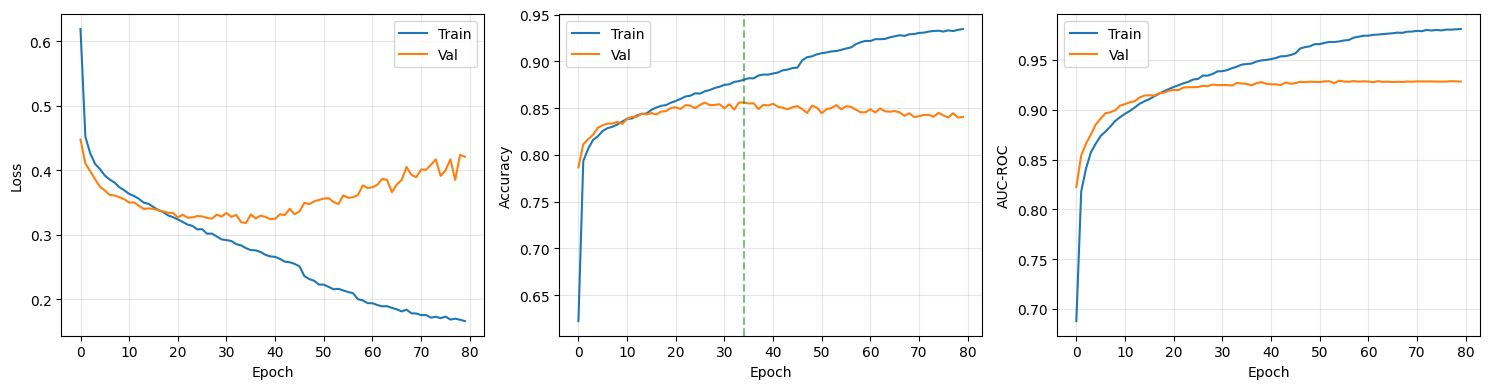

Training and model info
Training Duration: 2720.9 seconds (45.35 minutes)
Model Storage Size: 856.20 KB (0.84 MB)
Total Model Parameters: 215,931
Trainable Parameters: 215,931
Parameter Memory (float32): 0.82 MB
Best Validation Accuracy: 0.8560 (Epoch 35)
Encoding: iqp
Ansatz: strongly_entangling
Measurement: expval_z
Data Reuploading: False
Test Accuracy:  0.8551
Test F1-Score:  0.8500
Test AUC-ROC:   0.9233
Best Val Acc:   0.8560
Training Time:  2720.9s


In [ ]:
print("Loading features...")
X_features, version_data, y_labels, metadata, version_aware = load_defectors_features_from_drive()

print("\nPreparing data...")
(X_train, X_val, X_test, y_train, y_val, y_test,
 _, _, _, _, _, _) = prepare_data(
    X_features, None, y_labels, test_size=0.15, val_size=0.15,
    standardize=True, normalize=True
)

config = QuantumConfig(
    encoding_type='iqp',
    n_qubits=6,
    n_layers=2,
    ansatz_type='strongly_entangling',
    ansatz_params={
        'rotation': 'RY',
        'iqp_repeats': 2,
        'rotation_blocks': ['RY', 'RZ'],
        'entanglement': 'linear',
        'post_hidden_dims': [32, 16],
        'config_name': 'Config1'
    },
    measurement_type='expval_z',
    measurement_params={
        'n_pairs': 3,
    },
    use_dim_reduction=True,
    reduced_dim=6,
    dim_reduction_layers=[256, 64, 16],
    batch_size=256,
    learning_rate=0.001,
    epochs=80,
    dropout_pre=0.2,
    dropout_post=0.3,
    use_batch_norm=True,
    data_reuploading=False,
    reupload_layers=1
)

model = HybridQuantumClassifier(input_dim=X_train.shape[1], config=config)
trainer = QuantumTrainer(model, config)

stats = trainer.train(X_train, y_train, X_val, y_val)

results = trainer.evaluate(X_test, y_test, use_best_model=True)

trainer.plot_history(save_path='config1.png')

model_path = 'config1.pth'
torch.save(trainer.best_model_state, model_path)

print("Training and model info")
info = get_training_info(trainer, model, model_path)

print(f"Training Duration: {info['training_duration_seconds']:.1f} seconds ({info['training_duration_minutes']:.2f} minutes)")
print(f"Model Storage Size: {info['model_storage_kb']:.2f} KB ({info['model_storage_mb']:.2f} MB)")
print(f"Total Model Parameters: {info['total_parameters']:,}")
print(f"Trainable Parameters: {info['trainable_parameters']:,}")
print(f"Parameter Memory (float32): {info['parameter_memory_mb']:.2f} MB")
print(f"Best Validation Accuracy: {info['best_val_acc']:.4f} (Epoch {info['best_epoch']+1})")

print(f"Encoding: {config.encoding_type}")
print(f"Ansatz: {config.ansatz_type}")
print(f"Measurement: {config.measurement_type}")
print(f"Data Reuploading: {config.data_reuploading}")
print(f"Test Accuracy:  {results['accuracy']:.4f}")
print(f"Test F1-Score:  {results['f1_score']:.4f}")
print(f"Test AUC-ROC:   {results['auc']:.4f}")
print(f"Best Val Acc:   {trainer.best_val_acc:.4f}")
print(f"Training Time:  {stats.total_train_time:.1f}s")

###Config1.1

Loading features...
Mounting Google Drive...
Mounted at /content/drive
Found features file: /content/drive/MyDrive/Defectors_Project_Features/cls_vectors.parquet
File size: 180.97 MB
Total samples: 131,556
Feature dimension: 768
Defective: 65,778 (50.0%)
Clean: 65,778 (50.0%)
Contains NaN: False
Contains Inf: False
Feature range: [-0.1467, 0.7808]
Mean per dimension: 0.002295
Std per dimension: 0.004433

Preparing data...
Main features standardized
Main features L2 normalized
Data split
Train: 92,089 samples (49.9% defective)
Val:   19,733 samples (49.7% defective)
Test:  19,734 samples (50.5% defective)

Architechture: Config1_1
Input: 768 → 6 (reduction)
Quantum: 6 qubits, 2 layers
Encoding: IQP
Ansatz: Strongly Entangling
Measurement: expval_z
Data Reuploading: False (1 layers)
Post-NN: 6 → [4, 2] → 1
Total params: 465,139

Training: Config1_1
Parameters: 465,139 trainable
Device: cuda
Batch size: 256
Epochs: 80
Epoch   1/80 | Train Loss: 0.6659 | Train Acc: 0.5824 | Train AUC: 0.62

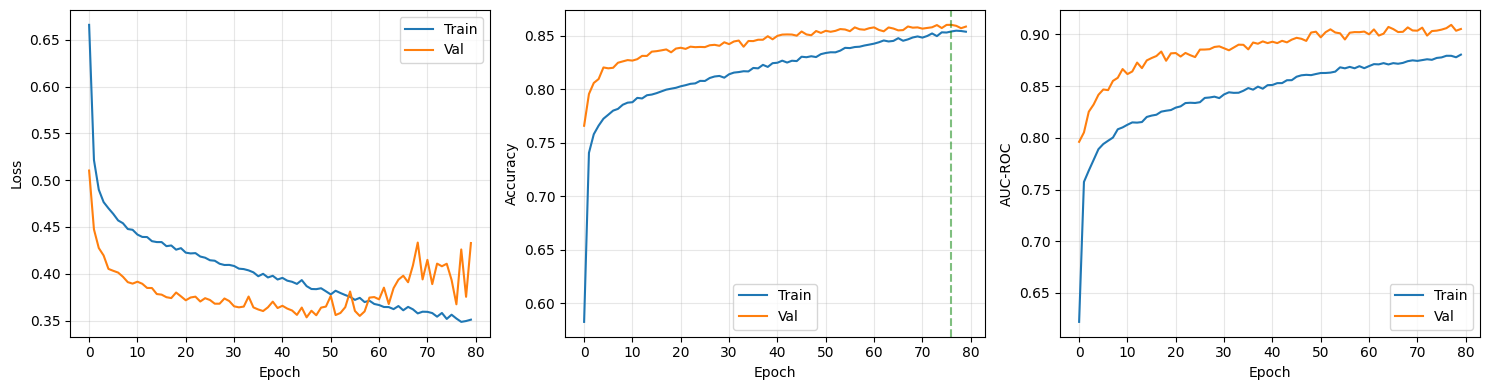

Training and model info
Training Duration: 2799.6 seconds (46.66 minutes)
Model Storage Size: 1832.77 KB (1.79 MB)
Total Model Parameters: 465,139
Trainable Parameters: 465,139
Parameter Memory (float32): 1.77 MB
Best Validation Accuracy: 0.8604 (Epoch 77)
Encoding: iqp
Ansatz: strongly_entangling
Measurement: expval_z
Data Reuploading: False
Test Accuracy:  0.8603
Test F1-Score:  0.8511
Test AUC-ROC:   0.9068
Best Val Acc:   0.8604
Training Time:  2799.6s


In [ ]:
print("Loading features...")
X_features, version_data, y_labels, metadata, version_aware = load_defectors_features_from_drive()

print("\nPreparing data...")
(X_train, X_val, X_test, y_train, y_val, y_test,
 _, _, _, _, _, _) = prepare_data(
    X_features, None, y_labels, test_size=0.15, val_size=0.15,
    standardize=True, normalize=True
)

config = QuantumConfig(
    encoding_type='iqp',
    n_qubits=6,
    n_layers=2,
    ansatz_type='strongly_entangling',
    ansatz_params={
        'rotation': 'RY',
        'iqp_repeats': 2,
        'rotation_blocks': ['RY', 'RZ'],
        'entanglement': 'linear',
        'post_hidden_dims': [4, 2],
        'config_name': 'Config1_1'
    },
    measurement_type='expval_z',
    measurement_params={
        'n_pairs': 3,
    },
    use_dim_reduction=True,
    reduced_dim=6,
    dim_reduction_layers=[512, 128, 32],
    batch_size=256,
    learning_rate=0.001,
    epochs=80,
    dropout_pre=0.2,
    dropout_post=0.3,
    use_batch_norm=True,
    data_reuploading=False,
    reupload_layers=1
)

model = HybridQuantumClassifier(input_dim=X_train.shape[1], config=config)
trainer = QuantumTrainer(model, config)

stats = trainer.train(X_train, y_train, X_val, y_val)

results = trainer.evaluate(X_test, y_test, use_best_model=True)

trainer.plot_history(save_path='config1_1.png')

model_path = 'config1_1.pth'
torch.save(trainer.best_model_state, model_path)

print("Training and model info")
info = get_training_info(trainer, model, model_path)

print(f"Training Duration: {info['training_duration_seconds']:.1f} seconds ({info['training_duration_minutes']:.2f} minutes)")
print(f"Model Storage Size: {info['model_storage_kb']:.2f} KB ({info['model_storage_mb']:.2f} MB)")
print(f"Total Model Parameters: {info['total_parameters']:,}")
print(f"Trainable Parameters: {info['trainable_parameters']:,}")
print(f"Parameter Memory (float32): {info['parameter_memory_mb']:.2f} MB")
print(f"Best Validation Accuracy: {info['best_val_acc']:.4f} (Epoch {info['best_epoch']+1})")

print(f"Encoding: {config.encoding_type}")
print(f"Ansatz: {config.ansatz_type}")
print(f"Measurement: {config.measurement_type}")
print(f"Data Reuploading: {config.data_reuploading}")
print(f"Test Accuracy:  {results['accuracy']:.4f}")
print(f"Test F1-Score:  {results['f1_score']:.4f}")
print(f"Test AUC-ROC:   {results['auc']:.4f}")
print(f"Best Val Acc:   {trainer.best_val_acc:.4f}")
print(f"Training Time:  {stats.total_train_time:.1f}s")

###Config 1.2

Loading features...
Found features file: /content/drive/MyDrive/Defectors_Project_Features/cls_vectors.parquet
File size: 180.97 MB
Total samples: 131,556
Feature dimension: 768
Defective: 65,778 (50.0%)
Clean: 65,778 (50.0%)
Contains NaN: False
Contains Inf: False
Feature range: [-0.1467, 0.7808]
Mean per dimension: 0.002295
Std per dimension: 0.004433

Preparing data...
Main features standardized
Main features L2 normalized
Data split
Train: 92,089 samples (49.9% defective)
Val:   19,733 samples (49.7% defective)
Test:  19,734 samples (50.5% defective)

Architechture: config1_2
Input: 768 → 6 (reduction)
Quantum: 6 qubits, 2 layers
Encoding: IQP
Ansatz: Strongly Entangling
Measurement: expval_z
Data Reuploading: False (1 layers)
Post-NN: 6 → [3] → 1
Total params: 465,123

Training: config1_2
Parameters: 465,123 trainable
Device: cuda
Batch size: 256
Epochs: 80
Epoch   1/80 | Train Loss: 0.6620 | Train Acc: 0.5856 | Train AUC: 0.6289 | Val Loss: 0.5099 | Val Acc: 0.7674 | Val AUC: 0.7

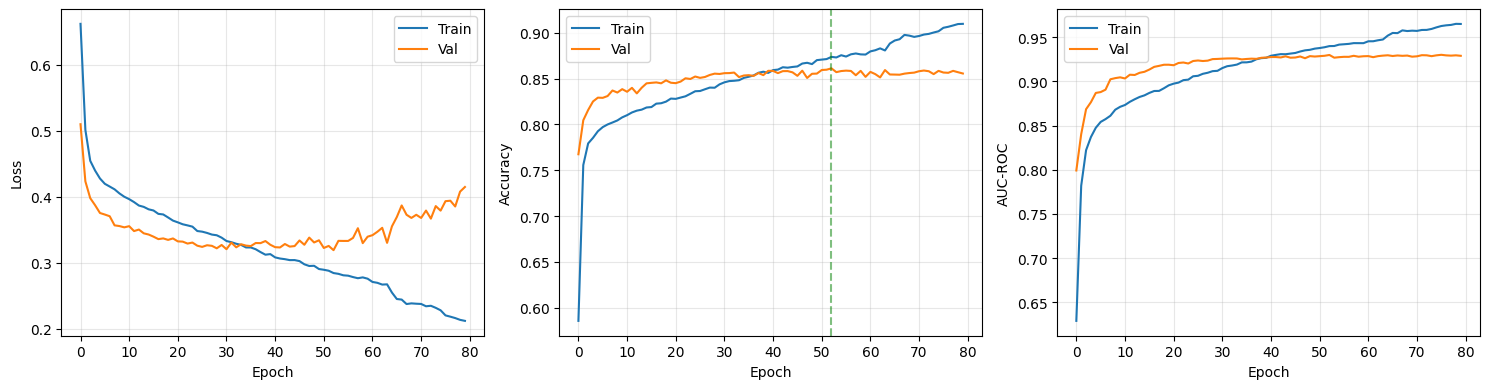

Training and model info
Training Duration: 2645.5 seconds (44.09 minutes)
Model Storage Size: 1832.08 KB (1.79 MB)
Total Model Parameters: 465,123
Trainable Parameters: 465,123
Parameter Memory (float32): 1.77 MB
Best Validation Accuracy: 0.8612 (Epoch 53)
Encoding: iqp
Ansatz: strongly_entangling
Measurement: expval_z
Data Reuploading: False
Test Accuracy:  0.8589
Test F1-Score:  0.8529
Test AUC-ROC:   0.9267
Best Val Acc:   0.8612
Training Time:  2645.5s


In [ ]:
print("Loading features...")
X_features, version_data, y_labels, metadata, version_aware = load_defectors_features_from_drive()

print("\nPreparing data...")
(X_train, X_val, X_test, y_train, y_val, y_test,
 _, _, _, _, _, _) = prepare_data(
    X_features, None, y_labels, test_size=0.15, val_size=0.15,
    standardize=True, normalize=True
)

config = QuantumConfig(
    encoding_type='iqp',
    n_qubits=6,
    n_layers=2,
    ansatz_type='strongly_entangling',
    ansatz_params={
        'rotation': 'RY',
        'iqp_repeats': 2,
        'rotation_blocks': ['RY', 'RZ'],
        'entanglement': 'linear',
        'post_hidden_dims': [3],
        'config_name': 'config1_2'
    },
    measurement_type='expval_z',
    measurement_params={
        'n_pairs': 3,
    },
    use_dim_reduction=True,
    reduced_dim=6,
    dim_reduction_layers=[512, 128, 32],
    batch_size=256,
    learning_rate=0.001,
    epochs=80,
    dropout_pre=0.2,
    dropout_post=0.3,
    use_batch_norm=True,
    data_reuploading=False,
    reupload_layers=1
)

model = HybridQuantumClassifier(input_dim=X_train.shape[1], config=config)
trainer = QuantumTrainer(model, config)

stats = trainer.train(X_train, y_train, X_val, y_val)

results = trainer.evaluate(X_test, y_test, use_best_model=True)

trainer.plot_history(save_path='config1_2.png')

model_path = 'config1_2.pth'
torch.save(trainer.best_model_state, model_path)

print("Training and model info")
info = get_training_info(trainer, model, model_path)

print(f"Training Duration: {info['training_duration_seconds']:.1f} seconds ({info['training_duration_minutes']:.2f} minutes)")
print(f"Model Storage Size: {info['model_storage_kb']:.2f} KB ({info['model_storage_mb']:.2f} MB)")
print(f"Total Model Parameters: {info['total_parameters']:,}")
print(f"Trainable Parameters: {info['trainable_parameters']:,}")
print(f"Parameter Memory (float32): {info['parameter_memory_mb']:.2f} MB")
print(f"Best Validation Accuracy: {info['best_val_acc']:.4f} (Epoch {info['best_epoch']+1})")

print(f"Encoding: {config.encoding_type}")
print(f"Ansatz: {config.ansatz_type}")
print(f"Measurement: {config.measurement_type}")
print(f"Data Reuploading: {config.data_reuploading}")
print(f"Test Accuracy:  {results['accuracy']:.4f}")
print(f"Test F1-Score:  {results['f1_score']:.4f}")
print(f"Test AUC-ROC:   {results['auc']:.4f}")
print(f"Best Val Acc:   {trainer.best_val_acc:.4f}")
print(f"Training Time:  {stats.total_train_time:.1f}s")

##Config 2

Loading features...
Found features file: /content/drive/MyDrive/Defectors_Project_Features/cls_vectors.parquet
File size: 180.97 MB
Total samples: 131,556
Feature dimension: 768
Defective: 65,778 (50.0%)
Clean: 65,778 (50.0%)
Contains NaN: False
Contains Inf: False
Feature range: [-0.1467, 0.7808]
Mean per dimension: 0.002295
Std per dimension: 0.004433

Preparing data...
Main features standardized
Main features L2 normalized
Data split
Train: 92,089 samples (49.9% defective)
Val:   19,733 samples (49.7% defective)
Test:  19,734 samples (50.5% defective)

Architechture: Config2
Input: 768 → 12 (reduction)
Quantum: 6 qubits, 2 layers
Encoding: ANGLE
Ansatz: Strongly Entangling
Measurement: expval_z
Data Reuploading: True (1 layers)
Post-NN: 6 → [32, 16] → 1
Total params: 216,033

Training: Config2
Parameters: 216,033 trainable
Device: cuda
Batch size: 256
Epochs: 80
Epoch   1/80 | Train Loss: 0.5376 | Train Acc: 0.7128 | Train AUC: 0.7887 | Val Loss: 0.3918 | Val Acc: 0.8132 | Val AUC: 

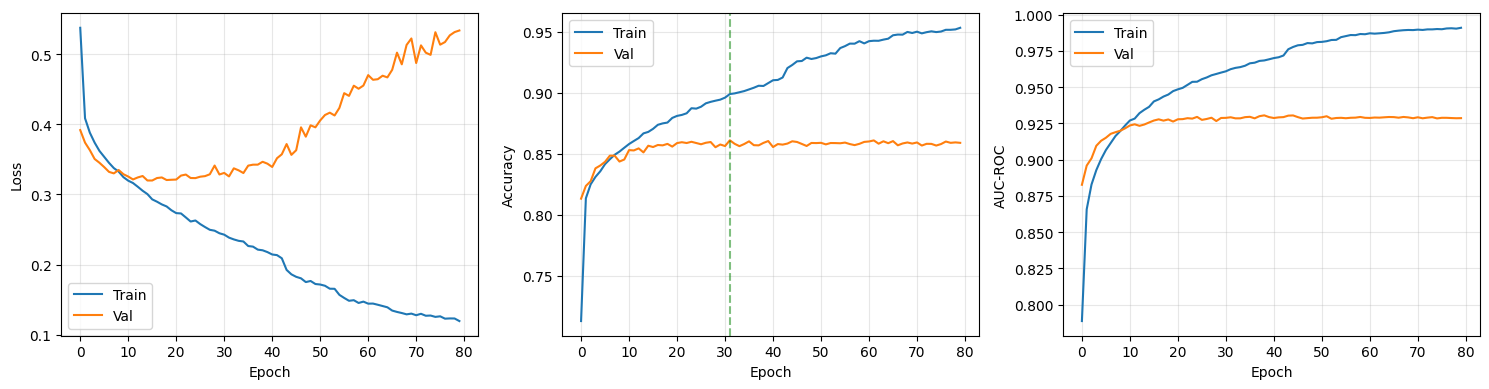

Training and model info
Training Duration: 1775.2 seconds (29.59 minutes)
Model Storage Size: 856.57 KB (0.84 MB)
Total Model Parameters: 216,033
Trainable Parameters: 216,033
Parameter Memory (float32): 0.82 MB
Best Validation Accuracy: 0.8611 (Epoch 32)
Encoding: angle
Ansatz: strongly_entangling
Measurement: expval_z
Data Reuploading: True
Reduced Dim: 12
Test Accuracy:  0.8586
Test F1-Score:  0.8499
Test AUC-ROC:   0.9269
Best Val Acc:   0.8611
Training Time:  1775.2s


In [ ]:
print("Loading features...")
X_features, version_data, y_labels, metadata, version_aware = load_defectors_features_from_drive()

print("\nPreparing data...")
(X_train, X_val, X_test, y_train, y_val, y_test,
 _, _, _, _, _, _) = prepare_data(
    X_features, None, y_labels, test_size=0.15, val_size=0.15,
    standardize=True, normalize=True
)

config = QuantumConfig(
    encoding_type='angle',
    n_qubits=6,
    n_layers=2,
    ansatz_type='strongly_entangling',
    ansatz_params={
        'rotation': 'RY',
        'iqp_repeats': 2,
        'rotation_blocks': ['RY', 'RZ'],
        'entanglement': 'linear',
        'post_hidden_dims': [32, 16],
        'config_name': 'Config2'
    },
    measurement_type='expval_z',
    measurement_params={
        'n_pairs': 3,
    },
    use_dim_reduction=True,
    reduced_dim=12,
    dim_reduction_layers=[256, 64, 16],
    batch_size=256,
    learning_rate=0.001,
    epochs=80,
    dropout_pre=0.2,
    dropout_post=0.3,
    use_batch_norm=True,
    data_reuploading=True,
    reupload_layers=1
)

model = HybridQuantumClassifier(input_dim=X_train.shape[1], config=config)
trainer = QuantumTrainer(model, config)

stats = trainer.train(X_train, y_train, X_val, y_val)

results = trainer.evaluate(X_test, y_test, use_best_model=True)

trainer.plot_history(save_path='Config2.png')

model_path = 'Config2.pth'
torch.save(trainer.best_model_state, model_path)

print("Training and model info")
info = get_training_info(trainer, model, model_path)

print(f"Training Duration: {info['training_duration_seconds']:.1f} seconds ({info['training_duration_minutes']:.2f} minutes)")
print(f"Model Storage Size: {info['model_storage_kb']:.2f} KB ({info['model_storage_mb']:.2f} MB)")
print(f"Total Model Parameters: {info['total_parameters']:,}")
print(f"Trainable Parameters: {info['trainable_parameters']:,}")
print(f"Parameter Memory (float32): {info['parameter_memory_mb']:.2f} MB")
print(f"Best Validation Accuracy: {info['best_val_acc']:.4f} (Epoch {info['best_epoch']+1})")

print(f"Encoding: {config.encoding_type}")
print(f"Ansatz: {config.ansatz_type}")
print(f"Measurement: {config.measurement_type}")
print(f"Data Reuploading: {config.data_reuploading}")
print(f"Reduced Dim: {config.reduced_dim}")
print(f"Test Accuracy:  {results['accuracy']:.4f}")
print(f"Test F1-Score:  {results['f1_score']:.4f}")
print(f"Test AUC-ROC:   {results['auc']:.4f}")
print(f"Best Val Acc:   {trainer.best_val_acc:.4f}")
print(f"Training Time:  {stats.total_train_time:.1f}s")

##Config3

Loading features...
Found features file: /content/drive/MyDrive/Defectors_Project_Features/cls_vectors.parquet
File size: 180.97 MB
Total samples: 131,556
Feature dimension: 768
Defective: 65,778 (50.0%)
Clean: 65,778 (50.0%)
Contains NaN: False
Contains Inf: False
Feature range: [-0.1467, 0.7808]
Mean per dimension: 0.002295
Std per dimension: 0.004433

Preparing data...
Main features standardized
Main features L2 normalized
Data split
Train: 92,089 samples (49.9% defective)
Val:   19,733 samples (49.7% defective)
Test:  19,734 samples (50.5% defective)

Architechture: config3
Input: 768 → 12 (reduction)
Quantum: 6 qubits, 2 layers
Encoding: DENSE
Ansatz: Strongly Entangling
Measurement: expval_z
Data Reuploading: False (1 layers)
Post-NN: 6 → [32, 16] → 1
Total params: 216,033

Training: config3
Parameters: 216,033 trainable
Device: cuda
Batch size: 256
Epochs: 80
Epoch   1/80 | Train Loss: 0.5544 | Train Acc: 0.6926 | Train AUC: 0.7591 | Val Loss: 0.4204 | Val Acc: 0.8048 | Val AUC:

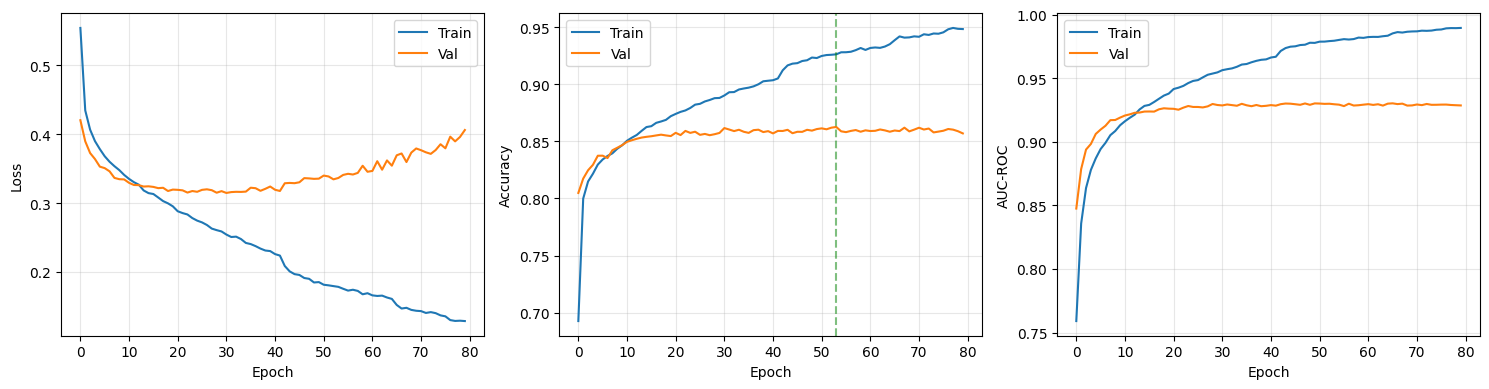

Training and model info
Training Duration: 1944.7 seconds (32.41 minutes)
Model Storage Size: 856.57 KB (0.84 MB)
Total Model Parameters: 216,033
Trainable Parameters: 216,033
Parameter Memory (float32): 0.82 MB
Best Validation Accuracy: 0.8626 (Epoch 54)
Encoding: dense
Ansatz: strongly_entangling
Measurement: expval_z
Data Reuploading: False
Reduced Dim: 12
Test Accuracy:  0.8601
Test F1-Score:  0.8554
Test AUC-ROC:   0.9271
Best Val Acc:   0.8626
Training Time:  1944.7s


In [ ]:
print("Loading features...")
X_features, version_data, y_labels, metadata, version_aware = load_defectors_features_from_drive()

print("\nPreparing data...")
(X_train, X_val, X_test, y_train, y_val, y_test,
 _, _, _, _, _, _) = prepare_data(
    X_features, None, y_labels, test_size=0.15, val_size=0.15,
    standardize=True, normalize=True
)

config = QuantumConfig(
    encoding_type='dense',
    n_qubits=6,
    n_layers=2,
    ansatz_type='strongly_entangling',
    ansatz_params={
        'rotation': 'RY',
        'iqp_repeats': 2,
        'rotation_blocks': ['RY', 'RZ'],
        'entanglement': 'linear',
        'post_hidden_dims': [32, 16],
        'config_name': 'config3'
    },
    measurement_type='expval_z',
    measurement_params={
        'n_pairs': 3,
    },
    use_dim_reduction=True,
    reduced_dim=12,
    dim_reduction_layers=[256, 64, 16],
    batch_size=256,
    learning_rate=0.001,
    epochs=80,
    dropout_pre=0.2,
    dropout_post=0.3,
    use_batch_norm=True,
    data_reuploading=False,
    reupload_layers=1
)

model = HybridQuantumClassifier(input_dim=X_train.shape[1], config=config)
trainer = QuantumTrainer(model, config)

stats = trainer.train(X_train, y_train, X_val, y_val)

results = trainer.evaluate(X_test, y_test, use_best_model=True)

trainer.plot_history(save_path='config3.png')

model_path = 'config3.pth'
torch.save(trainer.best_model_state, model_path)

print("Training and model info")
info = get_training_info(trainer, model, model_path)

print(f"Training Duration: {info['training_duration_seconds']:.1f} seconds ({info['training_duration_minutes']:.2f} minutes)")
print(f"Model Storage Size: {info['model_storage_kb']:.2f} KB ({info['model_storage_mb']:.2f} MB)")
print(f"Total Model Parameters: {info['total_parameters']:,}")
print(f"Trainable Parameters: {info['trainable_parameters']:,}")
print(f"Parameter Memory (float32): {info['parameter_memory_mb']:.2f} MB")
print(f"Best Validation Accuracy: {info['best_val_acc']:.4f} (Epoch {info['best_epoch']+1})")

print(f"Encoding: {config.encoding_type}")
print(f"Ansatz: {config.ansatz_type}")
print(f"Measurement: {config.measurement_type}")
print(f"Data Reuploading: {config.data_reuploading}")
print(f"Reduced Dim: {config.reduced_dim}")
print(f"Test Accuracy:  {results['accuracy']:.4f}")
print(f"Test F1-Score:  {results['f1_score']:.4f}")
print(f"Test AUC-ROC:   {results['auc']:.4f}")
print(f"Best Val Acc:   {trainer.best_val_acc:.4f}")
print(f"Training Time:  {stats.total_train_time:.1f}s")

##Config 4

Loading features...
Found features file: /content/drive/MyDrive/Defectors_Project_Features/cls_vectors.parquet
File size: 180.97 MB
Total samples: 131,556
Feature dimension: 768
Defective: 65,778 (50.0%)
Clean: 65,778 (50.0%)
Contains NaN: False
Contains Inf: False
Feature range: [-0.1467, 0.7808]
Mean per dimension: 0.002295
Std per dimension: 0.004433

Preparing data...
Main features standardized
Main features L2 normalized
Data split
Train: 92,089 samples (49.9% defective)
Val:   19,733 samples (49.7% defective)
Test:  19,734 samples (50.5% defective)

Architechture: config4
Input: 768 → 64 (reduction)
Quantum: 6 qubits, 2 layers
Encoding: AMPLITUDE
Ansatz: Strongly Entangling
Measurement: expval_z
Data Reuploading: False (1 layers)
Post-NN: 6 → [32, 16] → 1
Total params: 243,877

Training: config4
Parameters: 243,877 trainable
Device: cuda
Batch size: 256
Epochs: 80
Epoch   1/80 | Train Loss: 0.4651 | Train Acc: 0.7726 | Train AUC: 0.8353 | Val Loss: 0.3785 | Val Acc: 0.8249 | Val 

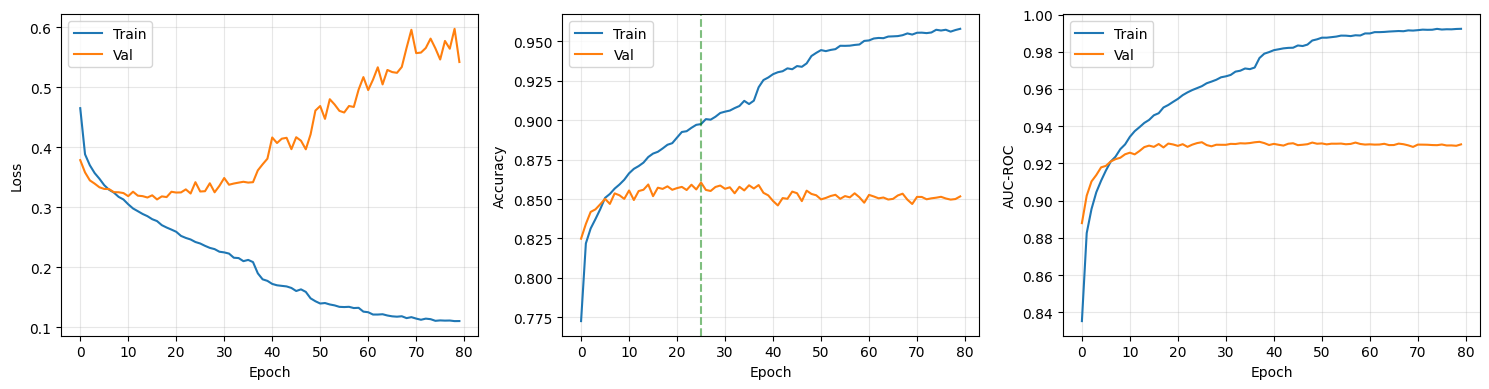

Training and model info
Training Duration: 1380.3 seconds (23.01 minutes)
Model Storage Size: 966.26 KB (0.94 MB)
Total Model Parameters: 243,877
Trainable Parameters: 243,877
Parameter Memory (float32): 0.93 MB
Best Validation Accuracy: 0.8605 (Epoch 26)
Encoding: amplitude
Ansatz: strongly_entangling
Measurement: expval_z
Data Reuploading: False
Reduced Dim: 64
Test Accuracy:  0.8597
Test F1-Score:  0.8535
Test AUC-ROC:   0.9281
Best Val Acc:   0.8605
Training Time:  1380.3s


In [ ]:
print("Loading features...")
X_features, version_data, y_labels, metadata, version_aware = load_defectors_features_from_drive()

print("\nPreparing data...")
(X_train, X_val, X_test, y_train, y_val, y_test,
 _, _, _, _, _, _) = prepare_data(
    X_features, None, y_labels, test_size=0.15, val_size=0.15,
    standardize=True, normalize=True
)

config = QuantumConfig(
    encoding_type='amplitude',
    n_qubits=6,
    n_layers=2,
    ansatz_type='strongly_entangling',
    ansatz_params={
        'rotation': 'RY',
        'iqp_repeats': 2,
        'rotation_blocks': ['RY', 'RZ'],
        'entanglement': 'linear',
        'post_hidden_dims': [32, 16],
        'config_name': 'config4'
    },
    measurement_type='expval_z',
    measurement_params={
        'n_pairs': 3,
    },
    use_dim_reduction=True,
    reduced_dim=64,
    dim_reduction_layers=[256, 128, 64],
    batch_size=256,
    learning_rate=0.001,
    epochs=80,
    dropout_pre=0.2,
    dropout_post=0.3,
    use_batch_norm=True,
    data_reuploading=False,
    reupload_layers=1
)

model = HybridQuantumClassifier(input_dim=X_train.shape[1], config=config)
trainer = QuantumTrainer(model, config)

stats = trainer.train(X_train, y_train, X_val, y_val)

results = trainer.evaluate(X_test, y_test, use_best_model=True)

trainer.plot_history(save_path='config4.png')

model_path = 'config4.pth'
torch.save(trainer.best_model_state, model_path)

print("Training and model info")
info = get_training_info(trainer, model, model_path)

print(f"Training Duration: {info['training_duration_seconds']:.1f} seconds ({info['training_duration_minutes']:.2f} minutes)")
print(f"Model Storage Size: {info['model_storage_kb']:.2f} KB ({info['model_storage_mb']:.2f} MB)")
print(f"Total Model Parameters: {info['total_parameters']:,}")
print(f"Trainable Parameters: {info['trainable_parameters']:,}")
print(f"Parameter Memory (float32): {info['parameter_memory_mb']:.2f} MB")
print(f"Best Validation Accuracy: {info['best_val_acc']:.4f} (Epoch {info['best_epoch']+1})")

print(f"Encoding: {config.encoding_type}")
print(f"Ansatz: {config.ansatz_type}")
print(f"Measurement: {config.measurement_type}")
print(f"Data Reuploading: {config.data_reuploading}")
print(f"Reduced Dim: {config.reduced_dim}")
print(f"Test Accuracy:  {results['accuracy']:.4f}")
print(f"Test F1-Score:  {results['f1_score']:.4f}")
print(f"Test AUC-ROC:   {results['auc']:.4f}")
print(f"Best Val Acc:   {trainer.best_val_acc:.4f}")
print(f"Training Time:  {stats.total_train_time:.1f}s")

##Config 5

Loading features...
Found features file: /content/drive/MyDrive/Defectors_Project_Features/cls_vectors.parquet
File size: 180.97 MB
Total samples: 131,556
Feature dimension: 768
Defective: 65,778 (50.0%)
Clean: 65,778 (50.0%)
Contains NaN: False
Contains Inf: False
Feature range: [-0.1467, 0.7808]
Mean per dimension: 0.002295
Std per dimension: 0.004433

Preparing data...
Main features standardized
Main features L2 normalized
Data split
Train: 92,089 samples (49.9% defective)
Val:   19,733 samples (49.7% defective)
Test:  19,734 samples (50.5% defective)

Architechture: config5
Input: 768 → 12 (reduction)
Quantum: 6 qubits, 2 layers
Encoding: EFFICIENT_SU2
Ansatz: Strongly Entangling
Measurement: expval_z
Data Reuploading: False (1 layers)
Post-NN: 6 → [32, 16] → 1
Total params: 240,497

Training: config5
Parameters: 240,497 trainable
Device: cuda
Batch size: 256
Epochs: 80
Epoch   1/80 | Train Loss: 0.5671 | Train Acc: 0.6866 | Train AUC: 0.7543 | Val Loss: 0.4323 | Val Acc: 0.8023 | 

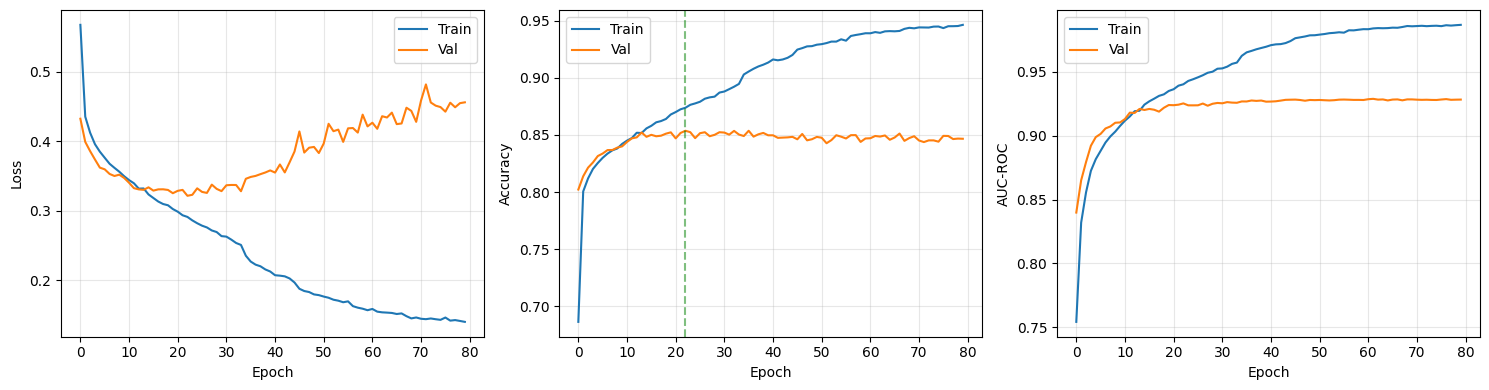

Training and model info
Training Duration: 2298.9 seconds (38.32 minutes)
Model Storage Size: 953.01 KB (0.93 MB)
Total Model Parameters: 240,497
Trainable Parameters: 240,497
Parameter Memory (float32): 0.92 MB
Best Validation Accuracy: 0.8536 (Epoch 23)
Encoding: efficient_su2
Ansatz: strongly_entangling
Measurement: expval_z
Data Reuploading: False
Reduced Dim: 12
Test Accuracy:  0.8521
Test F1-Score:  0.8464
Test AUC-ROC:   0.9230
Best Val Acc:   0.8536
Training Time:  2298.9s


In [ ]:
print("Loading features...")
X_features, version_data, y_labels, metadata, version_aware = load_defectors_features_from_drive()

print("\nPreparing data...")
(X_train, X_val, X_test, y_train, y_val, y_test,
 _, _, _, _, _, _) = prepare_data(
    X_features, None, y_labels, test_size=0.15, val_size=0.15,
    standardize=True, normalize=True
)

config = QuantumConfig(
    encoding_type='efficient_su2',
    n_qubits=6,
    n_layers=2,
    ansatz_type='strongly_entangling',
    ansatz_params={
        'rotation': 'RY',
        'iqp_repeats': 2,
        'rotation_blocks': ['RY', 'RZ'],
        'entanglement': 'linear',
        'su2_reps': 1,
        'post_hidden_dims': [32, 16],
        'config_name': 'config5'
    },
    measurement_type='expval_z',
    measurement_params={
        'n_pairs': 3,
    },
    use_dim_reduction=True,
    reduced_dim=12,
    dim_reduction_layers=[256, 128, 64],
    batch_size=256,
    learning_rate=0.001,
    epochs=80,
    dropout_pre=0.2,
    dropout_post=0.3,
    use_batch_norm=True,
    data_reuploading=False,
    reupload_layers=1
)

model = HybridQuantumClassifier(input_dim=X_train.shape[1], config=config)
trainer = QuantumTrainer(model, config)

stats = trainer.train(X_train, y_train, X_val, y_val)

results = trainer.evaluate(X_test, y_test, use_best_model=True)

trainer.plot_history(save_path='config5.png')

model_path = 'config5.pth'
torch.save(trainer.best_model_state, model_path)

print("Training and model info")
info = get_training_info(trainer, model, model_path)

print(f"Training Duration: {info['training_duration_seconds']:.1f} seconds ({info['training_duration_minutes']:.2f} minutes)")
print(f"Model Storage Size: {info['model_storage_kb']:.2f} KB ({info['model_storage_mb']:.2f} MB)")
print(f"Total Model Parameters: {info['total_parameters']:,}")
print(f"Trainable Parameters: {info['trainable_parameters']:,}")
print(f"Parameter Memory (float32): {info['parameter_memory_mb']:.2f} MB")
print(f"Best Validation Accuracy: {info['best_val_acc']:.4f} (Epoch {info['best_epoch']+1})")

print(f"Encoding: {config.encoding_type}")
print(f"Ansatz: {config.ansatz_type}")
print(f"Measurement: {config.measurement_type}")
print(f"Data Reuploading: {config.data_reuploading}")
print(f"Reduced Dim: {config.reduced_dim}")
print(f"Test Accuracy:  {results['accuracy']:.4f}")
print(f"Test F1-Score:  {results['f1_score']:.4f}")
print(f"Test AUC-ROC:   {results['auc']:.4f}")
print(f"Best Val Acc:   {trainer.best_val_acc:.4f}")
print(f"Training Time:  {stats.total_train_time:.1f}s")

##Config 6

In [ ]:
print("Loading features...")
X_features, version_data, y_labels, metadata, version_aware = load_defectors_features_from_drive()

print("\nPreparing data...")
(X_train, X_val, X_test, y_train, y_val, y_test,
 _, _, _, _, _, _) = prepare_data(
    X_features, None, y_labels, test_size=0.15, val_size=0.15,
    standardize=True, normalize=True
)

config = QuantumConfig(
    encoding_type='iqp',
    n_qubits=6,
    n_layers=2,
    ansatz_type='simplified_two_design',
    ansatz_params={
        'rotation': 'RY',
        'iqp_repeats': 2,
        'rotation_blocks': ['RY', 'RZ'],
        'entanglement': 'linear',
        'post_hidden_dims': [3],
        'config_name': 'config 6'
    },
    measurement_type='expval_z',
    measurement_params={
        'n_pairs': 3,
    },
    use_dim_reduction=True,
    reduced_dim=6,
    dim_reduction_layers=[512, 128, 32],
    batch_size=256,
    learning_rate=0.001,
    epochs=80,
    dropout_pre=0.2,
    dropout_post=0.3,
    use_batch_norm=True,
    data_reuploading=False,
    reupload_layers=1
)

model = HybridQuantumClassifier(input_dim=X_train.shape[1], config=config)
trainer = QuantumTrainer(model, config)

stats = trainer.train(X_train, y_train, X_val, y_val)

results = trainer.evaluate(X_test, y_test, use_best_model=True)

trainer.plot_history(save_path='config 6')

model_path = 'config 6.pth'
torch.save(trainer.best_model_state, model_path)

print("Training and model info")
info = get_training_info(trainer, model, model_path)

print(f"Training Duration: {info['training_duration_seconds']:.1f} seconds ({info['training_duration_minutes']:.2f} minutes)")
print(f"Model Storage Size: {info['model_storage_kb']:.2f} KB ({info['model_storage_mb']:.2f} MB)")
print(f"Total Model Parameters: {info['total_parameters']:,}")
print(f"Trainable Parameters: {info['trainable_parameters']:,}")
print(f"Parameter Memory (float32): {info['parameter_memory_mb']:.2f} MB")
print(f"Best Validation Accuracy: {info['best_val_acc']:.4f} (Epoch {info['best_epoch']+1})")

print(f"Encoding: {config.encoding_type}")
print(f"Ansatz: {config.ansatz_type}")
print(f"Measurement: {config.measurement_type}")
print(f"Data Reuploading: {config.data_reuploading}")
print(f"Test Accuracy:  {results['accuracy']:.4f}")
print(f"Test F1-Score:  {results['f1_score']:.4f}")
print(f"Test AUC-ROC:   {results['auc']:.4f}")
print(f"Best Val Acc:   {trainer.best_val_acc:.4f}")
print(f"Training Time:  {stats.total_train_time:.1f}s")

Loading features...
Found features file: /content/drive/MyDrive/Defectors_Project_Features/cls_vectors.parquet
File size: 180.97 MB
Total samples: 131,556
Feature dimension: 768
Defective: 65,778 (50.0%)
Clean: 65,778 (50.0%)
Contains NaN: False
Contains Inf: False
Feature range: [-0.1467, 0.7808]
Mean per dimension: 0.002295
Std per dimension: 0.004433

Preparing data...
Main features standardized
Main features L2 normalized
Data split
Train: 92,089 samples (49.9% defective)
Val:   19,733 samples (49.7% defective)
Test:  19,734 samples (50.5% defective)

Architechture: config 6
Input: 768 → 6 (reduction)
Quantum: 6 qubits, 2 layers
Encoding: IQP
Ansatz: Simplified Two Design
Measurement: expval_z
Data Reuploading: False (1 layers)
Post-NN: 6 → [3] → 1
Total params: 465,123

Training: config 6
Parameters: 465,123 trainable
Device: cuda
Batch size: 256
Epochs: 80
Epoch   1/80 | Train Loss: 0.6063 | Train Acc: 0.6570 | Train AUC: 0.7201 | Val Loss: 0.4741 | Val Acc: 0.7952 | Val AUC: 0.8

##Config 7

Loading features...
Mounting Google Drive...
Mounted at /content/drive
Found features file: /content/drive/MyDrive/Defectors_Project_Features/cls_vectors.parquet
File size: 180.97 MB
Total samples: 131,556
Feature dimension: 768
Defective: 65,778 (50.0%)
Clean: 65,778 (50.0%)
Contains NaN: False
Contains Inf: False
Feature range: [-0.1467, 0.7808]
Mean per dimension: 0.002295
Std per dimension: 0.004433

Preparing data...
Main features standardized
Main features L2 normalized
Data split
Train: 92,089 samples (49.9% defective)
Val:   19,733 samples (49.7% defective)
Test:  19,734 samples (50.5% defective)

Architechture: config 7
Input: 768 → 6 (reduction)
Quantum: 6 qubits, 2 layers
Encoding: IQP
Ansatz: Basic Entangler
Measurement: expval_z
Data Reuploading: False (1 layers)
Post-NN: 6 → [3] → 1
Total params: 465,099

Training: config 7
Parameters: 465,099 trainable
Device: cuda
Batch size: 256
Epochs: 80
Epoch   1/80 | Train Loss: 0.6041 | Train Acc: 0.6427 | Train AUC: 0.7089 | Val 

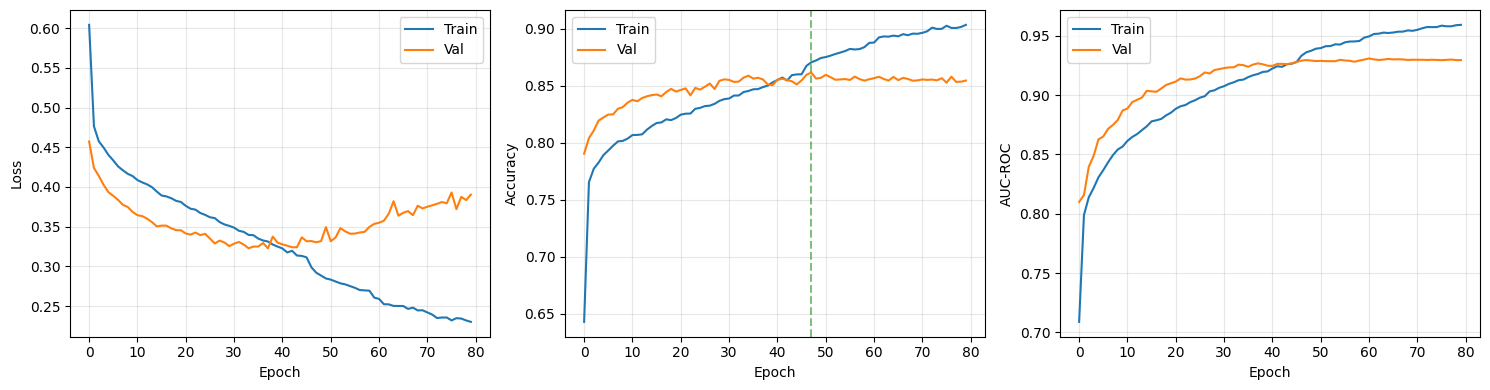

Training and model info
Training Duration: 2311.6 seconds (38.53 minutes)
Model Storage Size: 1831.92 KB (1.79 MB)
Total Model Parameters: 465,099
Trainable Parameters: 465,099
Parameter Memory (float32): 1.77 MB
Best Validation Accuracy: 0.8617 (Epoch 48)
Encoding: iqp
Ansatz: basic_entangler
Measurement: expval_z
Data Reuploading: False
Test Accuracy:  0.8590
Test F1-Score:  0.8546
Test AUC-ROC:   0.9272
Best Val Acc:   0.8617
Training Time:  2311.6s


In [ ]:
print("Loading features...")
X_features, version_data, y_labels, metadata, version_aware = load_defectors_features_from_drive()

print("\nPreparing data...")
(X_train, X_val, X_test, y_train, y_val, y_test,
 _, _, _, _, _, _) = prepare_data(
    X_features, None, y_labels, test_size=0.15, val_size=0.15,
    standardize=True, normalize=True
)

config = QuantumConfig(
    encoding_type='iqp',
    n_qubits=6,
    n_layers=2,
    ansatz_type='basic_entangler',
    ansatz_params={
        'rotation': 'RY',
        'iqp_repeats': 2,
        'rotation_blocks': ['RY', 'RZ'],
        'entanglement': 'linear',
        'post_hidden_dims': [3],
        'config_name': 'config 7'
    },
    measurement_type='expval_z',
    measurement_params={
        'n_pairs': 3,
    },
    use_dim_reduction=True,
    reduced_dim=6,
    dim_reduction_layers=[512, 128, 32],
    batch_size=256,
    learning_rate=0.001,
    epochs=80,
    dropout_pre=0.2,
    dropout_post=0.3,
    use_batch_norm=True,
    data_reuploading=False,
    reupload_layers=1
)

model = HybridQuantumClassifier(input_dim=X_train.shape[1], config=config)
trainer = QuantumTrainer(model, config)

stats = trainer.train(X_train, y_train, X_val, y_val)

results = trainer.evaluate(X_test, y_test, use_best_model=True)

trainer.plot_history(save_path='config 7.png')

model_path = 'config 7.pth'
torch.save(trainer.best_model_state, model_path)

print("Training and model info")
info = get_training_info(trainer, model, model_path)

print(f"Training Duration: {info['training_duration_seconds']:.1f} seconds ({info['training_duration_minutes']:.2f} minutes)")
print(f"Model Storage Size: {info['model_storage_kb']:.2f} KB ({info['model_storage_mb']:.2f} MB)")
print(f"Total Model Parameters: {info['total_parameters']:,}")
print(f"Trainable Parameters: {info['trainable_parameters']:,}")
print(f"Parameter Memory (float32): {info['parameter_memory_mb']:.2f} MB")
print(f"Best Validation Accuracy: {info['best_val_acc']:.4f} (Epoch {info['best_epoch']+1})")

print(f"Encoding: {config.encoding_type}")
print(f"Ansatz: {config.ansatz_type}")
print(f"Measurement: {config.measurement_type}")
print(f"Data Reuploading: {config.data_reuploading}")
print(f"Test Accuracy:  {results['accuracy']:.4f}")
print(f"Test F1-Score:  {results['f1_score']:.4f}")
print(f"Test AUC-ROC:   {results['auc']:.4f}")
print(f"Best Val Acc:   {trainer.best_val_acc:.4f}")
print(f"Training Time:  {stats.total_train_time:.1f}s")

##Config 8

In [ ]:
print("Loading features...")
X_features, version_data, y_labels, metadata, version_aware = load_defectors_features_from_drive()

print("\nPreparing data...")
(X_train, X_val, X_test, y_train, y_val, y_test,
 _, _, _, _, _, _) = prepare_data(
    X_features, None, y_labels, test_size=0.15, val_size=0.15,
    standardize=True, normalize=True
)

config = QuantumConfig(
    encoding_type='iqp',
    n_qubits=6,
    n_layers=2,
    ansatz_type='basic_entangler',
    ansatz_params={
        'rotation': 'RY',
        'iqp_repeats': 2,
        'rotation_blocks': ['RY', 'RZ'],
        'entanglement': 'linear',
        'post_hidden_dims': [3],
        'config_name': 'config 8'
    },
    measurement_type='expval_zx',
    measurement_params={
        'n_pairs': 3,
    },
    use_dim_reduction=True,
    reduced_dim=6,
    dim_reduction_layers=[256, 64, 16],
    batch_size=256,
    learning_rate=0.001,
    epochs=80,
    dropout_pre=0.2,
    dropout_post=0.3,
    use_batch_norm=True,
    data_reuploading=False,
    reupload_layers=1
)

model = HybridQuantumClassifier(input_dim=X_train.shape[1], config=config)
trainer = QuantumTrainer(model, config)

stats = trainer.train(X_train, y_train, X_val, y_val)

results = trainer.evaluate(X_test, y_test, use_best_model=True)

trainer.plot_history(save_path='config 8.png')

model_path = 'config 8.pth'
torch.save(trainer.best_model_state, model_path)

print("Training and model info")
info = get_training_info(trainer, model, model_path)

print(f"Training Duration: {info['training_duration_seconds']:.1f} seconds ({info['training_duration_minutes']:.2f} minutes)")
print(f"Model Storage Size: {info['model_storage_kb']:.2f} KB ({info['model_storage_mb']:.2f} MB)")
print(f"Total Model Parameters: {info['total_parameters']:,}")
print(f"Trainable Parameters: {info['trainable_parameters']:,}")
print(f"Parameter Memory (float32): {info['parameter_memory_mb']:.2f} MB")
print(f"Best Validation Accuracy: {info['best_val_acc']:.4f} (Epoch {info['best_epoch']+1})")

print(f"Encoding: {config.encoding_type}")
print(f"Ansatz: {config.ansatz_type}")
print(f"Measurement: {config.measurement_type}")
print(f"Data Reuploading: {config.data_reuploading}")
print(f"Test Accuracy:  {results['accuracy']:.4f}")
print(f"Test F1-Score:  {results['f1_score']:.4f}")
print(f"Test AUC-ROC:   {results['auc']:.4f}")
print(f"Best Val Acc:   {trainer.best_val_acc:.4f}")
print(f"Training Time:  {stats.total_train_time:.1f}s")

Loading features...
Found features file: /content/drive/MyDrive/Defectors_Project_Features/cls_vectors.parquet
File size: 180.97 MB
Total samples: 131,556
Feature dimension: 768
Defective: 65,778 (50.0%)
Clean: 65,778 (50.0%)
Contains NaN: False
Contains Inf: False
Feature range: [-0.1467, 0.7808]
Mean per dimension: 0.002295
Std per dimension: 0.004433

Preparing data...
Main features standardized
Main features L2 normalized
Data split
Train: 92,089 samples (49.9% defective)
Val:   19,733 samples (49.7% defective)
Test:  19,734 samples (50.5% defective)

Architechture: config 8
Input: 768 → 6 (reduction)
Quantum: 6 qubits, 2 layers
Encoding: IQP
Ansatz: Basic Entangler
Measurement: expval_zx
Data Reuploading: False (1 layers)
Post-NN: 6 → [3] → 1
Total params: 215,163

Training: config 8
Parameters: 215,163 trainable
Device: cuda
Batch size: 256
Epochs: 80
Epoch   1/80 | Train Loss: 0.6353 | Train Acc: 0.6383 | Train AUC: 0.6976 | Val Loss: 0.4940 | Val Acc: 0.7843 | Val AUC: 0.8598 -